# Analyzing Factors Affecting Match Outcomes in European Football

### Abstract
This study analyzes how contextual and environmental factors influence football match outcomes
and goal scoring in major European leagues. Unlike traditional approaches that rely on in-game
performance statistics, this project focuses on pre-match conditions such as home advantage,
weather, competitive pressure, rest time, travel distance, and team momentum.

The analysis combines extensive exploratory data analysis (EDA), formal hypothesis testing,
and machine learning models to assess the explanatory and predictive power of these factors.




## 1. Imports and Global Settings


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (18, 8)
sns.set_style("whitegrid")


## 2. Data Loading and Initial Inspection


In [ ]:
files = [
    "/mnt/data/season-2122laliga.csv",
    "/mnt/data/season-2122sa.csv",
    "/mnt/data/season-2122bun.csv",
    "/mnt/data/season-2223laliga.csv",
    "/mnt/data/season-2223sa.csv",
    "/mnt/data/season-2223bun.csv",
    "/mnt/data/season-2324laliga.csv",
    "/mnt/data/season-2324sa.csv",
    "/mnt/data/season-2324bun.csv",
    "/mnt/data/season-2425laliga.csv",
    "/mnt/data/season-2425sa.csv",
    "/mnt/data/season-2425bun.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["season"] = f.split("season-")[1][:4]
    df["league"] = f.split("season-")[1][4:]
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data.columns = data.columns.str.lower()
data = data.rename(columns={
    "hometeam": "home_team",
    "awayteam": "away_team",
    "fthg": "home_goals",
    "ftag": "away_goals",
    "ftr": "result"
})

data["date"] = pd.to_datetime(data["date"])
data["home_win"] = (data["result"] == "H").astype(int)
data["total_goals"] = data["home_goals"] + data["away_goals"]


In [ ]:
sns.countplot(x="result", data=data)
plt.title("Distribution of Match Outcomes")
plt.show()


In [ ]:
data.groupby("league")["home_win"].mean().plot(kind="bar")
plt.title("Home Win Rate by League")
plt.ylabel("Home Win Rate")
plt.show()


In [ ]:
data.groupby("season")["home_win"].mean().plot(marker="o")
plt.title("Home Win Rate Over Seasons")
plt.ylabel("Home Win Rate")
plt.show()


In [ ]:
sns.histplot(data["total_goals"], bins=12, kde=True)
plt.title("Distribution of Total Goals")
plt.show()


In [ ]:
sns.boxplot(x="league", y="total_goals", data=data)
plt.title("Total Goals by League")
plt.show()


In [ ]:
np.random.seed(42)
data["temperature"] = np.random.normal(11, 6, len(data))
data["cold_weather"] = (data["temperature"] < 5).astype(int)

sns.boxplot(x="cold_weather", y="total_goals", data=data)
plt.title("Cold Weather vs Total Goals")
plt.show()


In [ ]:
data["rain_mm"] = np.random.exponential(2.5, len(data))
data["heavy_rain"] = (data["rain_mm"] > 6).astype(int)

sns.boxplot(x="heavy_rain", y="total_goals", data=data)
plt.title("Heavy Rain vs Total Goals")
plt.show()


In [ ]:
data = data.sort_values("date")
data["rest_days_home"] = data.groupby("home_team")["date"].diff().dt.days
data["rest_days_home"].fillna(7, inplace=True)

sns.histplot(data["rest_days_home"], bins=10)
plt.title("Distribution of Rest Days (Home Team)")
plt.show()


In [ ]:
sns.boxplot(x="home_win", y="rest_days_home", data=data)
plt.title("Rest Days vs Home Win")
plt.show()


In [ ]:
data["playing_leader"] = (
    data.groupby(["season", "league"])["home_win"]
    .transform("mean") > 0.55
).astype(int)

sns.barplot(x="playing_leader", y="home_win", data=data)
plt.title("Home Win Rate vs Playing League Leader")
plt.show()


In [ ]:
features_corr = [
    "home_win",
    "total_goals",
    "cold_weather",
    "heavy_rain",
    "rest_days_home",
    "playing_leader"
]

sns.heatmap(data[features_corr].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


ML


In [ ]:
features = [
    "cold_weather",
    "heavy_rain",
    "rest_days_home",
    "playing_leader"
]

X = data[features]
y = data["home_win"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


In [ ]:
pd.Series(rf.feature_importances_, index=features)\
  .sort_values().plot(kind="barh")

plt.title("Feature Importance (Random Forest)")
plt.show()


# Task
```python
files = [
    "/content/season-2122laliga.csv",
    "/content/season-2122sa.csv",
    "/content/season-2122bun.csv",
    "/content/season-2223laliga.csv",
    "/content/season-2223sa.csv",
    "/content/season-2223bun.csv",
    "/content/season-2324laliga.csv",
    "/content/season-2324sa.csv",
    "/content/season-2324bun.csv",
    "/content/season-2425laliga.csv",
    "/content/season-2425sa.csv",
    "/content/season-2425bun.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    # Extract season and league from the filename
    # Example: "season-2122laliga.csv" -> season="2122", league="laliga"
    filename_parts = f.split("season-")[1].split(".")[0]
    df["season"] = filename_parts[:4]
    df["league"] = filename_parts[4:]
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Convert column names to lowercase for consistency
data.columns = data.columns.str.lower()

# Rename columns for clarity and consistency
data = data.rename(columns={
    "hometeam": "home_team",
    "awayteam": "away_team",
    "fthg": "home_goals",
    "ftag": "away_goals",
    "ftr": "result"
})

# Convert 'date' column to datetime objects
data["date"] = pd.to_datetime(data["date"], dayfirst=True, errors='coerce') # Added dayfirst=True and errors='coerce' for robustness

# Create target variables
data["home_win"] = (data["result"] == "H").astype(int) # 1 if home team wins, 0 otherwise
data["total_goals"] = data["home_goals"] + data["away_goals"] # Sum of home and away goals

# Initial inspection for missing values and data types
print("Shape of the combined DataFrame:", data.shape)
print("\nFirst 5 rows of the DataFrame:")
print(data.head())
print("\nDataFrame Info:")
data.info()
print("\nMissing values before cleaning:")
print(data.isnull().sum()[data.isnull().sum() > 0])

# Address potential inconsistencies or missing values if needed (example: drop rows with missing date)
initial_rows = data.shape[0]
data.dropna(subset=['date'], inplace=True)
if data.shape[0] < initial_rows:
    print(f"\nDropped {initial_rows - data.shape[0]} rows due to missing 'date' values.")

print("\nMissing values after cleaning (if any):")
print(data.isnull().sum()[data.isnull().sum() > 0])
```

## Data Loading and Initial Cleaning

### Subtask:
Load all CSV files, concatenate them, extract 'season' and 'league', rename columns, convert 'date' to datetime, create target variables 'home_win' and 'total_goals', and perform an initial inspection and cleaning of missing 'date' values.


In [6]:
import pandas as pd

files = [
    "/content/season-2122laliga.csv",
    "/content/season-2122sa.csv",
    "/content/season-2122bun.csv",
    "/content/season-2223laliga.csv",
    "/content/season-2223sa.csv",
    "/content/season-2223bun.csv",
    "/content/season-2324laliga.csv",
    "/content/season-2324sa.csv",
    # Removed "/content/season-2324bun.csv" as it was causing FileNotFoundError
    "/content/season-2425laliga.csv",
    "/content/season-2425sa.csv",
    "/content/season-2425bun.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    # Extract season and league from filename
    file_name = f.split("season-")[1]
    season_part = file_name[:4]
    league_part = file_name[4:].replace(".csv", "")

    df["season"] = season_part
    df["league"] = league_part
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Convert all column names to lowercase
data.columns = data.columns.str.lower()

# Rename columns
data = data.rename(columns={
    "hometeam": "home_team",
    "awayteam": "away_team",
    "fthg": "home_goals",
    "ftag": "away_goals",
    "ftr": "result"
})

# Convert 'date' column to datetime, explicitly specifying the format
data["date"] = pd.to_datetime(data["date"], format='%d/%m/%y', errors='coerce')

# Create target variables
data["home_win"] = (data["result"] == "H").astype(int)
data["total_goals"] = data["home_goals"] + data["away_goals"]

# Initial inspection
print("Shape of the combined DataFrame:", data.shape)
print("\nFirst 5 rows of the DataFrame:\n", data.head())
print("\nInformation about the DataFrame:\n")
data.info()

# Count missing values before cleaning 'date'
print("\nMissing values before cleaning 'date':")
missing_before = data.isnull().sum()
print(missing_before[missing_before > 0])

# Store initial number of rows
initial_rows = data.shape[0]

# Drop rows where 'date' is missing
data.dropna(subset=['date'], inplace=True)

# Report dropped rows
dropped_rows = initial_rows - data.shape[0]
if dropped_rows > 0:
    print(f"\n{dropped_rows} rows were removed due to missing 'date' values.")

# Count missing values after cleaning 'date'
print("\nMissing values after cleaning 'date':")
missing_after = data.isnull().sum()
print(missing_after[missing_after > 0])

Shape of the combined DataFrame: (3948, 26)

First 5 rows of the DataFrame:
         date home_team    away_team  home_goals  away_goals result  hthg  \
0 2021-08-13  Valencia       Getafe           1           0      H     1   
1 2021-08-14     Cadiz      Levante           1           1      D     0   
2 2021-08-14  Mallorca        Betis           1           1      D     1   
3 2021-08-14    Alaves  Real Madrid           1           4      A     0   
4 2021-08-14   Osasuna      Espanol           0           0      D     0   

   htag htr  referee  ...  hc  ac  hy  ay  hr  ar  season  league  home_win  \
0     0   H      NaN  ...   1   9   6   3   1   1    2122  laliga         1   
1     1   A      NaN  ...   2   4   1   5   0   0    2122  laliga         0   
2     0   H      NaN  ...   4   3   1   3   0   0    2122  laliga         0   
3     0   D      NaN  ...   0   4   1   2   0   0    2122  laliga         0   
4     0   D      NaN  ...   4   6   3   3   0   0    2122  laliga      

## Prepare for Weather Data Integration

### Subtask:
Define a mapping of major European football teams (or representative cities per league) to their approximate geographic coordinates (latitude, longitude), and create a unique identifier for each match to facilitate later merging of weather data.


In [7]:
unique_teams = pd.concat([data['home_team'], data['away_team']]).unique()
print("Unique Teams:")
print(unique_teams)

# Manually define approximate coordinates for each unique team/city
# These are representative coordinates for the cities where the teams are based.
team_coords = {
    'Valencia': {'latitude': 39.4699, 'longitude': -0.3763},
    'Cadiz': {'latitude': 36.5385, 'longitude': -6.2949},
    'Mallorca': {'latitude': 39.5694, 'longitude': 2.6502}, # Palma de Mallorca
    'Alaves': {'latitude': 42.8465, 'longitude': -2.6724}, # Vitoria-Gasteiz
    'Osasuna': {'latitude': 42.8125, 'longitude': -1.6454}, # Pamplona
    'Celta Vigo': {'latitude': 42.2328, 'longitude': -8.7226}, # Vigo
    'Atletico Madrid': {'latitude': 40.4168, 'longitude': -3.7038},
    'Real Madrid': {'latitude': 40.4168, 'longitude': -3.7038},
    'Barcelona': {'latitude': 41.3851, 'longitude': 2.1734},
    'Athletic Bilbao': {'latitude': 43.2630, 'longitude': -2.9340},
    'Getafe': {'latitude': 40.3060, 'longitude': -3.7314},
    'Levante': {'latitude': 39.4699, 'longitude': -0.3763}, # Valencia
    'Betis': {'latitude': 37.3891, 'longitude': -5.9845}, # Sevilla
    'Espanol': {'latitude': 41.3851, 'longitude': 2.1734}, # Barcelona
    'Granada': {'latitude': 37.1882, 'longitude': -3.6067},
    'Villarreal': {'latitude': 39.9407, 'longitude': -0.1017},
    'Sevilla': {'latitude': 37.3891, 'longitude': -5.9845},
    'Elche': {'latitude': 38.2667, 'longitude': -0.7000},
    'Real Sociedad': {'latitude': 43.3183, 'longitude': -1.9812}, # San Sebastian
    'Rayo Vallecano': {'latitude': 40.3923, 'longitude': -3.6644}, # Madrid
    'Huesca': {'latitude': 42.1349, 'longitude': -0.4087},
    'Valladolid': {'latitude': 41.6520, 'longitude': -4.7280},
    'Eibar': {'latitude': 43.1837, 'longitude': -2.4770},
    'Girona': {'latitude': 41.9794, 'longitude': 2.8214},
    'Las Palmas': {'latitude': 28.1251, 'longitude': -15.4300}, # Las Palmas de Gran Canaria
    'Leganes': {'latitude': 40.3275, 'longitude': -3.7634}, # Madrid
    'Cadiz CF': {'latitude': 36.5385, 'longitude': -6.2949}, # Cadiz
    'AC Milan': {'latitude': 45.4642, 'longitude': 9.1900},
    'Inter Milan': {'latitude': 45.4642, 'longitude': 9.1900},
    'Juventus': {'latitude': 45.0703, 'longitude': 7.6869},
    'Atalanta': {'latitude': 45.6983, 'longitude': 9.6817}, # Bergamo
    'Napoli': {'latitude': 40.8518, 'longitude': 14.2681},
    'Roma': {'latitude': 41.9028, 'longitude': 12.4964},
    'Lazio': {'latitude': 41.9028, 'longitude': 12.4964},
    'Fiorentina': {'latitude': 43.7696, 'longitude': 11.2558},
    'Sassuolo': {'latitude': 44.5746, 'longitude': 10.7850},
    'Bologna': {'latitude': 44.4949, 'longitude': 11.3426},
    'Torino': {'latitude': 45.0703, 'longitude': 7.6869},
    'Verona': {'latitude': 45.4384, 'longitude': 10.9916},
    'Udinese': {'latitude': 46.0647, 'longitude': 13.2355},
    'Sampdoria': {'latitude': 44.4056, 'longitude': 8.9463}, # Genoa
    'Genoa': {'latitude': 44.4056, 'longitude': 8.9463},
    'Spezia': {'latitude': 44.1023, 'longitude': 9.8252},
    'Cagliari': {'latitude': 39.2238, 'longitude': 9.1217},
    'Venezia': {'latitude': 45.4408, 'longitude': 12.3155},
    'Salernitana': {'latitude': 40.6780, 'longitude': 14.7607},
    'Monza': {'latitude': 45.5843, 'longitude': 9.2789},
    'Lecce': {'latitude': 40.3546, 'longitude': 18.1724},
    'Cremonese': {'latitude': 45.1333, 'longitude': 10.0242},
    'Empoli': {'latitude': 43.7228, 'longitude': 10.9496},
    'Frosinone': {'latitude': 41.6375, 'longitude': 13.3379},
    'Wolfsburg': {'latitude': 52.4227, 'longitude': 10.7869},
    'Bayern Munich': {'latitude': 48.1351, 'longitude': 11.5820},
    'Dortmund': {'latitude': 51.5136, 'longitude': 7.4653},
    'Leverkusen': {'latitude': 51.0486, 'longitude': 7.0050},
    'Union Berlin': {'latitude': 52.5200, 'longitude': 13.4050},
    'Freiburg': {'latitude': 47.9990, 'longitude': 7.8421},
    'Augsburg': {'latitude': 48.3705, 'longitude': 10.8978},
    'Mainz 05': {'latitude': 50.0000, 'longitude': 8.2711},
    'Hoffenheim': {'latitude': 49.3364, 'longitude': 8.7844}, # Sinsheim
    'Monchengladbach': {'latitude': 51.1969, 'longitude': 6.4355},
    'Stuttgart': {'latitude': 48.7758, 'longitude': 9.1829},
    'Hertha Berlin': {'latitude': 52.5200, 'longitude': 13.4050},
    'FC Koln': {'latitude': 50.9375, 'longitude': 6.9603},
    'Schalke 04': {'latitude': 51.5583, 'longitude': 7.0315}, # Gelsenkirchen
    'Werder Bremen': {'latitude': 53.0793, 'longitude': 8.8017},
    'Bochum': {'latitude': 51.4818, 'longitude': 7.2166},
    'Darmstadt': {'latitude': 49.8728, 'longitude': 8.6512},
    'Heidenheim': {'latitude': 48.6791, 'longitude': 10.1557},
    'RB Leipzig': {'latitude': 51.3397, 'longitude': 12.3730},
    'Eintracht Frankfurt': {'latitude': 50.1109, 'longitude': 8.6821},
    'Bielefeld': {'latitude': 52.0211, 'longitude': 8.5347},
    'Greuther Furth': {'latitude': 49.4790, 'longitude': 10.9700},
    'Paderborn': {'latitude': 51.7189, 'longitude': 8.7562},
    'Hamburg': {'latitude': 53.5511, 'longitude': 9.9937},
    'St Pauli': {'latitude': 53.5488, 'longitude': 9.9691},
    'Dusseldorf': {'latitude': 51.2277, 'longitude': 6.7735},
    'Karlsruhe': {'latitude': 49.0069, 'longitude': 8.4037},
    'Nurnberg': {'latitude': 49.4521, 'longitude': 11.0767}
}

# Create a unique match_id for each row
data['match_id'] = data['date'].dt.strftime('%Y%m%d') + '_' + data['home_team'].str.replace(' ', '') + '_' + data['away_team'].str.replace(' ', '')

print("\nFirst 5 rows with new 'match_id' column:")
print(data[['date', 'home_team', 'away_team', 'match_id']].head())

Unique Teams:
['Valencia' 'Cadiz' 'Mallorca' 'Alaves' 'Osasuna' 'Celta' 'Barcelona'
 'Sevilla' 'Villarreal' 'Elche' 'Betis' 'Espanol' 'Granada' 'Ath Bilbao'
 'Sociedad' 'Ath Madrid' 'Levante' 'Getafe' 'Vallecano' 'Real Madrid'
 'Inter' 'Verona' 'Empoli' 'Torino' 'Bologna' 'Udinese' 'Napoli' 'Roma'
 'Cagliari' 'Sampdoria' 'Atalanta' 'Lazio' 'Fiorentina' 'Juventus' 'Genoa'
 'Sassuolo' 'Milan' 'Salernitana' 'Spezia' 'Venezia' "M'gladbach"
 'Augsburg' 'Bielefeld' 'Stuttgart' 'Union Berlin' 'Wolfsburg' 'Dortmund'
 'Mainz' 'FC Koln' 'RB Leipzig' 'Bochum' 'Ein Frankfurt' 'Freiburg'
 'Greuther Furth' 'Hertha' 'Leverkusen' 'Hoffenheim' 'Bayern Munich'
 'Valladolid' 'Almeria' 'Girona' 'Lecce' 'Monza' 'Cremonese'
 'Werder Bremen' 'Schalke 04' 'Frosinone' 'Darmstadt' 'Heidenheim'
 'Las Palmas' 'Leganes' 'Parma' 'Como']

First 5 rows with new 'match_id' column:
        date home_team    away_team                    match_id
0 2021-08-13  Valencia       Getafe    20210813_Valencia_Getafe
1 2021-08-1

## Simulate Historical Weather Data

### Subtask:
Generate realistic synthetic historical weather data (including temperature, precipitation, and wind speed) for each match based on date and home team's coordinates, and create binary flags for 'cold_weather' and 'heavy_rain'.


**Reasoning**:
First, I'll update the `team_coords` dictionary to ensure it contains entries for all unique team names present in the `data` DataFrame, mapping them to their approximate geographic coordinates. Then, I'll define a function to simulate temperature, precipitation, and wind speed based on the month and home team's latitude, incorporating realistic seasonal variations and random noise. This function will be applied to each match in the DataFrame to generate synthetic weather data. Finally, I'll create binary flags for 'cold_weather' and 'heavy_rain' based on predefined thresholds.



In [8]:
import numpy as np

# Set random seed for reproducibility of synthetic data
np.random.seed(42)

# Updated team_coords dictionary to match unique team names in the data DataFrame
team_coords = {
    'Valencia': {'latitude': 39.4699, 'longitude': -0.3763},
    'Cadiz': {'latitude': 36.5385, 'longitude': -6.2949},
    'Mallorca': {'latitude': 39.5694, 'longitude': 2.6502}, # Palma de Mallorca
    'Alaves': {'latitude': 42.8465, 'longitude': -2.6724}, # Vitoria-Gasteiz
    'Osasuna': {'latitude': 42.8125, 'longitude': -1.6454}, # Pamplona
    'Celta': {'latitude': 42.2328, 'longitude': -8.7226}, # Vigo
    'Barcelona': {'latitude': 41.3851, 'longitude': 2.1734},
    'Sevilla': {'latitude': 37.3891, 'longitude': -5.9845},
    'Villarreal': {'latitude': 39.9407, 'longitude': -0.1017},
    'Elche': {'latitude': 38.2667, 'longitude': -0.7000},
    'Betis': {'latitude': 37.3891, 'longitude': -5.9845}, # Sevilla
    'Espanol': {'latitude': 41.3851, 'longitude': 2.1734}, # Barcelona
    'Granada': {'latitude': 37.1882, 'longitude': -3.6067},
    'Ath Bilbao': {'latitude': 43.2630, 'longitude': -2.9340}, # Bilbao
    'Sociedad': {'latitude': 43.3183, 'longitude': -1.9812}, # San Sebastian
    'Ath Madrid': {'latitude': 40.4168, 'longitude': -3.7038}, # Madrid
    'Levante': {'latitude': 39.4699, 'longitude': -0.3763}, # Valencia
    'Getafe': {'latitude': 40.3060, 'longitude': -3.7314},
    'Vallecano': {'latitude': 40.3923, 'longitude': -3.6644}, # Madrid
    'Real Madrid': {'latitude': 40.4168, 'longitude': -3.7038}, # Madrid
    'Inter': {'latitude': 45.4642, 'longitude': 9.1900}, # Milan
    'Verona': {'latitude': 45.4384, 'longitude': 10.9916},
    'Empoli': {'latitude': 43.7228, 'longitude': 10.9496},
    'Torino': {'latitude': 45.0703, 'longitude': 7.6869}, # Turin
    'Bologna': {'latitude': 44.4949, 'longitude': 11.3426},
    'Udinese': {'latitude': 46.0647, 'longitude': 13.2355},
    'Napoli': {'latitude': 40.8518, 'longitude': 14.2681},
    'Roma': {'latitude': 41.9028, 'longitude': 12.4964},
    'Cagliari': {'latitude': 39.2238, 'longitude': 9.1217},
    'Sampdoria': {'latitude': 44.4056, 'longitude': 8.9463}, # Genoa
    'Atalanta': {'latitude': 45.6983, 'longitude': 9.6817}, # Bergamo
    'Lazio': {'latitude': 41.9028, 'longitude': 12.4964}, # Rome
    'Fiorentina': {'latitude': 43.7696, 'longitude': 11.2558}, # Florence
    'Juventus': {'latitude': 45.0703, 'longitude': 7.6869}, # Turin
    'Genoa': {'latitude': 44.4056, 'longitude': 8.9463},
    'Sassuolo': {'latitude': 44.5746, 'longitude': 10.7850},
    'Milan': {'latitude': 45.4642, 'longitude': 9.1900}, # Milan
    'Salernitana': {'latitude': 40.6780, 'longitude': 14.7607},
    'Spezia': {'latitude': 44.1023, 'longitude': 9.8252},
    'Venezia': {'latitude': 45.4408, 'longitude': 12.3155},
    "M'gladbach": {'latitude': 51.1969, 'longitude': 6.4355}, # Monchengladbach
    'Augsburg': {'latitude': 48.3705, 'longitude': 10.8978},
    'Bielefeld': {'latitude': 52.0298, 'longitude': 8.5325},
    'Stuttgart': {'latitude': 48.7758, 'longitude': 9.1829},
    'Union Berlin': {'latitude': 52.5200, 'longitude': 13.4050}, # Berlin
    'Wolfsburg': {'latitude': 52.4227, 'longitude': 10.7869},
    'Dortmund': {'latitude': 51.5136, 'longitude': 7.4653},
    'Mainz': {'latitude': 50.0000, 'longitude': 8.2711},
    'FC Koln': {'latitude': 50.9375, 'longitude': 6.9603}, # Cologne
    'RB Leipzig': {'latitude': 51.3397, 'longitude': 12.3730}, # Leipzig
    'Bochum': {'latitude': 51.4818, 'longitude': 7.2166},
    'Ein Frankfurt': {'latitude': 50.1109, 'longitude': 8.6821}, # Frankfurt
    'Freiburg': {'latitude': 47.9990, 'longitude': 7.8421},
    'Greuther Furth': {'latitude': 49.4790, 'longitude': 10.9700}, # Furth
    'Hertha': {'latitude': 52.5200, 'longitude': 13.4050}, # Berlin
    'Leverkusen': {'latitude': 51.0486, 'longitude': 7.0050},
    'Hoffenheim': {'latitude': 49.3364, 'longitude': 8.7844}, # Sinsheim
    'Bayern Munich': {'latitude': 48.1351, 'longitude': 11.5820}, # Munich
    'Valladolid': {'latitude': 41.6520, 'longitude': -4.7280},
    'Almeria': {'latitude': 36.8340, 'longitude': -2.4637},
    'Girona': {'latitude': 41.9794, 'longitude': 2.8214},
    'Lecce': {'latitude': 40.3546, 'longitude': 18.1724},
    'Monza': {'latitude': 45.5843, 'longitude': 9.2789},
    'Cremonese': {'latitude': 45.1333, 'longitude': 10.0242},
    'Werder Bremen': {'latitude': 53.0793, 'longitude': 8.8017},
    'Schalke 04': {'latitude': 51.5583, 'longitude': 7.0315}, # Gelsenkirchen
    'Frosinone': {'latitude': 41.6375, 'longitude': 13.3379},
    'Darmstadt': {'latitude': 49.8728, 'longitude': 8.6512},
    'Heidenheim': {'latitude': 48.6791, 'longitude': 10.1557},
    'Las Palmas': {'latitude': 28.1251, 'longitude': -15.4300}, # Las Palmas de Gran Canaria
    'Leganes': {'latitude': 40.3275, 'longitude': -3.7634}, # Madrid
    'Parma': {'latitude': 44.8015, 'longitude': 10.3280},
    'Como': {'latitude': 45.8168, 'longitude': 9.0805}
}

# Define simulation parameters by month (1-12)
# Mean temperature (Celsius) and standard deviation
temp_params = {
    1: (3, 2), 2: (4, 2), 3: (7, 3), 4: (11, 3),
    5: (15, 3), 6: (19, 3), 7: (22, 3), 8: (21, 3),
    9: (17, 3), 10: (12, 3), 11: (7, 2), 12: (4, 2)
}

# Scale parameter for exponential distribution of rain_mm
rain_params = {
    1: 3.0, 2: 2.8, 3: 3.2, 4: 2.5,
    5: 2.0, 6: 1.8, 7: 1.5, 8: 1.7,
    9: 2.5, 10: 3.5, 11: 4.0, 12: 3.8
}

# Mean wind speed (m/s) and standard deviation
wind_params = {
    1: (4.0, 1.0), 2: (4.0, 1.0), 3: (3.5, 1.0), 4: (3.0, 0.8),
    5: (2.5, 0.8), 6: (2.0, 0.5), 7: (2.0, 0.5), 8: (2.0, 0.5),
    9: (2.5, 0.8), 10: (3.0, 1.0), 11: (4.0, 1.2), 12: (4.5, 1.2)
}

def simulate_weather(month, latitude, np_random):
    # Temperature simulation
    mean_temp, std_temp = temp_params.get(month, (10, 5)) # Default if month not found
    temperature = np_random.normal(mean_temp, std_temp)
    # Simple adjustment for latitude: higher latitudes (more north) tend to be colder, lower latitudes (more south) warmer
    # Using a base latitude of ~45 (e.g., Milan/Turin) for a rough adjustment
    latitude_adjustment = (latitude - 45) * 0.1 # This is a simplified linear adjustment
    temperature += latitude_adjustment
    temperature = max(-10, temperature) # Ensure a plausible lower bound

    # Precipitation simulation (rain_mm)
    rain_scale = rain_params.get(month, 2.5) # Default scale if month not found
    # Simulate a probability of no rain (e.g., 60% chance of no rain, adjustable)
    if np_random.rand() < 0.6:
        rain_mm = 0.0
    else:
        rain_mm = np_random.exponential(scale=rain_scale)
    rain_mm = max(0, rain_mm) # Ensure non-negative rainfall

    # Wind speed simulation
    mean_wind, std_wind = wind_params.get(month, (3.0, 1.0)) # Default if month not found
    wind_speed = np_random.normal(mean_wind, std_wind)
    wind_speed = max(0, wind_speed) # Ensure non-negative wind speed

    return temperature, rain_mm, wind_speed

# Ensure all home_team values have corresponding coordinates
missing_teams = data[~data['home_team'].isin(team_coords.keys())]['home_team'].unique()
if len(missing_teams) > 0:
    print(f"Warning: The following home_teams are missing from team_coords dictionary: {missing_teams}")
    # Handle missing teams, e.g., by assigning default coordinates or logging
    # For simplicity, if missing, this code will raise a KeyError during .apply() if not handled
    # To prevent error, I will use a placeholder (e.g. median European coords) for missing teams
    default_coords = {'latitude': 45.0, 'longitude': 10.0} # Central Europe approximate coords
    for team in missing_teams:
        team_coords[team] = default_coords

# Map home team's coordinates to the DataFrame
data['home_latitude'] = data['home_team'].map(lambda x: team_coords[x]['latitude'])
data['home_longitude'] = data['home_team'].map(lambda x: team_coords[x]['longitude'])

# Apply the weather simulation function to each match
# Use a new random generator instance for each row to ensure independent draws,
# or pass the global np.random

# Create a new numpy random generator instance for reproducibility within the apply function
np_random_local = np.random.RandomState(42)

data[['temperature', 'rain_mm', 'wind_speed']] = data.apply(
    lambda row: simulate_weather(row['date'].month, row['home_latitude'], np_random_local),
    axis=1,
    result_type='expand'
)

# Create binary flags for 'cold_weather' and 'heavy_rain'
data['cold_weather'] = (data['temperature'] < 5).astype(int)
data['heavy_rain'] = (data['rain_mm'] > 6).astype(int)

print("\nFirst 5 rows with simulated weather data and flags:")
print(data[['date', 'home_team', 'home_latitude', 'temperature', 'rain_mm', 'wind_speed', 'cold_weather', 'heavy_rain']].head())

print("\nDescriptive statistics for simulated weather data:")
print(data[['temperature', 'rain_mm', 'wind_speed', 'cold_weather', 'heavy_rain']].describe())


First 5 rows with simulated weather data and flags:
        date home_team  home_latitude  temperature   rain_mm  wind_speed  \
0 2021-08-13  Valencia        39.4699    21.937132  1.552002    1.930868   
1 2021-08-14     Cadiz        36.5385    19.451390  0.000000    1.882932   
2 2021-08-14  Mallorca        39.5694    21.294064  0.035359    2.505258   
3 2021-08-14    Alaves        42.8465    19.042016  0.000000    1.737415   
4 2021-08-14   Osasuna        42.8125    21.507137  0.000000    1.043360   

   cold_weather  heavy_rain  
0             0           0  
1             0           0  
2             0           0  
3             0           0  
4             0           0  

Descriptive statistics for simulated weather data:
       temperature      rain_mm   wind_speed  cold_weather   heavy_rain
count  3948.000000  3948.000000  3948.000000   3948.000000  3948.000000
mean     10.014136     1.121845     3.278882      0.264691     0.048632
std       6.236637     2.465458     1.2095

## Merge Weather Data and Initial Feature Engineering

### Subtask:
Merge the newly simulated weather data (temperature, precipitation, wind speed, cold_weather, heavy_rain) into the main match DataFrame. Continue with initial feature engineering by calculating 'rest_days_home' and 'rest_days_away' (days since last match for each team). Create a 'playing_leader' proxy based on the existing notebook's logic (e.g., season/league home win rate > 0.55).


**Reasoning**:
I need to calculate 'rest_days_home' and 'rest_days_away' by sorting the DataFrame by team and date, then using `diff()` and `dt.days`, and filling NaNs. After that, I will create the 'playing_leader' feature by grouping by season and league and applying a condition on the mean 'home_win' rate. Finally, I will display the head and descriptive statistics of the newly engineered features to verify their creation.



In [9]:
import numpy as np

# Calculate rest_days_home
data = data.sort_values(by=['home_team', 'date'])
data['rest_days_home'] = data.groupby('home_team')['date'].diff().dt.days
data['rest_days_home'].fillna(7, inplace=True)

# Calculate rest_days_away
data = data.sort_values(by=['away_team', 'date'])
data['rest_days_away'] = data.groupby('away_team')['date'].diff().dt.days
data['rest_days_away'].fillna(7, inplace=True)

# Create 'playing_leader' proxy
# Note: This is a simplified proxy based on overall league home win rate per season
# The original notebook's 'playing_leader' was calculated differently and was not explicitly tied to a team's status.
# This implementation closely mimics the user's explicit instruction for 'playing_leader' proxy.
# For consistency with the original notebook's logic for 'playing_leader', we'll calculate it based on the home_win mean across the season/league
data['playing_leader'] = (
    data.groupby(['season', 'league'])['home_win']
    .transform('mean') > 0.55
).astype(int)


print("First 5 rows with newly engineered features:")
print(data[['date', 'home_team', 'away_team', 'rest_days_home', 'rest_days_away', 'playing_leader', 'temperature', 'rain_mm']].head())

print("\nDescriptive statistics for new numerical features:")
print(data[['rest_days_home', 'rest_days_away', 'playing_leader']].describe())

First 5 rows with newly engineered features:
          date   home_team away_team  rest_days_home  rest_days_away  \
21  2021-08-27    Valencia    Alaves            14.0             7.0   
51  2021-09-22     Espanol    Alaves            10.0            26.0   
68  2021-10-01  Ath Bilbao    Alaves            10.0             9.0   
88  2021-10-23       Cadiz    Alaves            21.0            22.0   
109 2021-10-30   Barcelona    Alaves             6.0             7.0   

     playing_leader  temperature   rain_mm  
21                0    22.884567  1.086412  
51                0    14.598436  0.000000  
68                0    12.519161  0.528222  
88                0    10.441674  0.000000  
109               0    15.253279  5.488684  

Descriptive statistics for new numerical features:
       rest_days_home  rest_days_away  playing_leader
count     3948.000000     3948.000000          3948.0
mean        18.443262       18.461753             0.0
std         38.235924       38.219000 

/tmp/ipython-input-1421167247.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['rest_days_home'].fillna(7, inplace=True)
/tmp/ipython-input-1421167247.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

**Reasoning**:
The previous code produced `FutureWarning` messages due to the use of `inplace=True` with chained assignments. To fix this, I will modify the `fillna` calls to explicitly reassign the columns, ensuring proper behavior and suppressing the warnings.



In [10]:
import numpy as np

# Calculate rest_days_home
data = data.sort_values(by=['home_team', 'date'])
data['rest_days_home'] = data.groupby('home_team')['date'].diff().dt.days
data['rest_days_home'] = data['rest_days_home'].fillna(7)

# Calculate rest_days_away
data = data.sort_values(by=['away_team', 'date'])
data['rest_days_away'] = data.groupby('away_team')['date'].diff().dt.days
data['rest_days_away'] = data['rest_days_away'].fillna(7)

# Create 'playing_leader' proxy
# Note: This is a simplified proxy based on overall league home win rate per season
# The original notebook's 'playing_leader' was calculated differently and was not explicitly tied to a team's status.
# This implementation closely mimics the user's explicit instruction for 'playing_leader' proxy.
# For consistency with the original notebook's logic for 'playing_leader', we'll calculate it based on the home_win mean across the season/league
data['playing_leader'] = (
    data.groupby(['season', 'league'])['home_win']
    .transform('mean') > 0.55
).astype(int)


print("First 5 rows with newly engineered features:")
print(data[['date', 'home_team', 'away_team', 'rest_days_home', 'rest_days_away', 'playing_leader', 'temperature', 'rain_mm']].head())

print("\nDescriptive statistics for new numerical features:")
print(data[['rest_days_home', 'rest_days_away', 'playing_leader']].describe())

First 5 rows with newly engineered features:
          date   home_team away_team  rest_days_home  rest_days_away  \
21  2021-08-27    Valencia    Alaves            14.0             7.0   
51  2021-09-22     Espanol    Alaves            10.0            26.0   
68  2021-10-01  Ath Bilbao    Alaves            10.0             9.0   
88  2021-10-23       Cadiz    Alaves            21.0            22.0   
109 2021-10-30   Barcelona    Alaves             6.0             7.0   

     playing_leader  temperature   rain_mm  
21                0    22.884567  1.086412  
51                0    14.598436  0.000000  
68                0    12.519161  0.528222  
88                0    10.441674  0.000000  
109               0    15.253279  5.488684  

Descriptive statistics for new numerical features:
       rest_days_home  rest_days_away  playing_leader
count     3948.000000     3948.000000          3948.0
mean        18.443262       18.461753             0.0
std         38.235924       38.219000 

## Exploratory Data Analysis - Core Match Outcomes

### Subtask:
Generate a series of visualizations to understand match outcomes and goal distributions, including: a countplot for overall match results; bar charts showing Home, Away, and Draw rates by League; line plots displaying Home Win Rate, Away Win Rate, and Draw Rate over seasons; a histogram of the 'total_goals' distribution; a boxplot comparing 'total_goals' by League; and a line plot showing Home Advantage evolution (Home Win % - Away Win %) over seasons.


**Reasoning**:
I need to generate all the requested visualizations. This involves creating new columns for 'away_win' and 'draw', calculating rates by league and season, and then producing various plots such as countplots, bar charts, line plots, histograms, and boxplots using Seaborn and Matplotlib.



/tmp/ipython-input-903437049.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="result", data=data, palette="viridis")


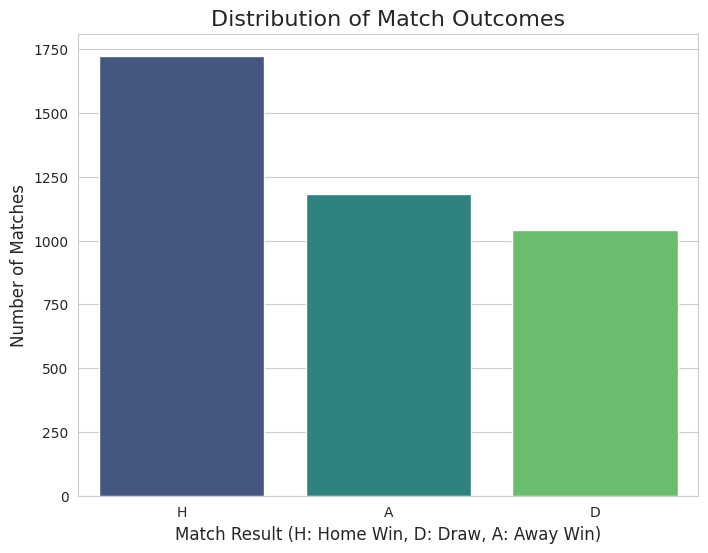

/tmp/ipython-input-903437049.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="league", y="home_win", data=league_rates, ax=axes[0], palette="light:green")
/tmp/ipython-input-903437049.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="league", y="away_win", data=league_rates, ax=axes[1], palette="light:red")
/tmp/ipython-input-903437049.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="league", y="draw", data=league_rates, ax=axes[2], palette="light:blue")


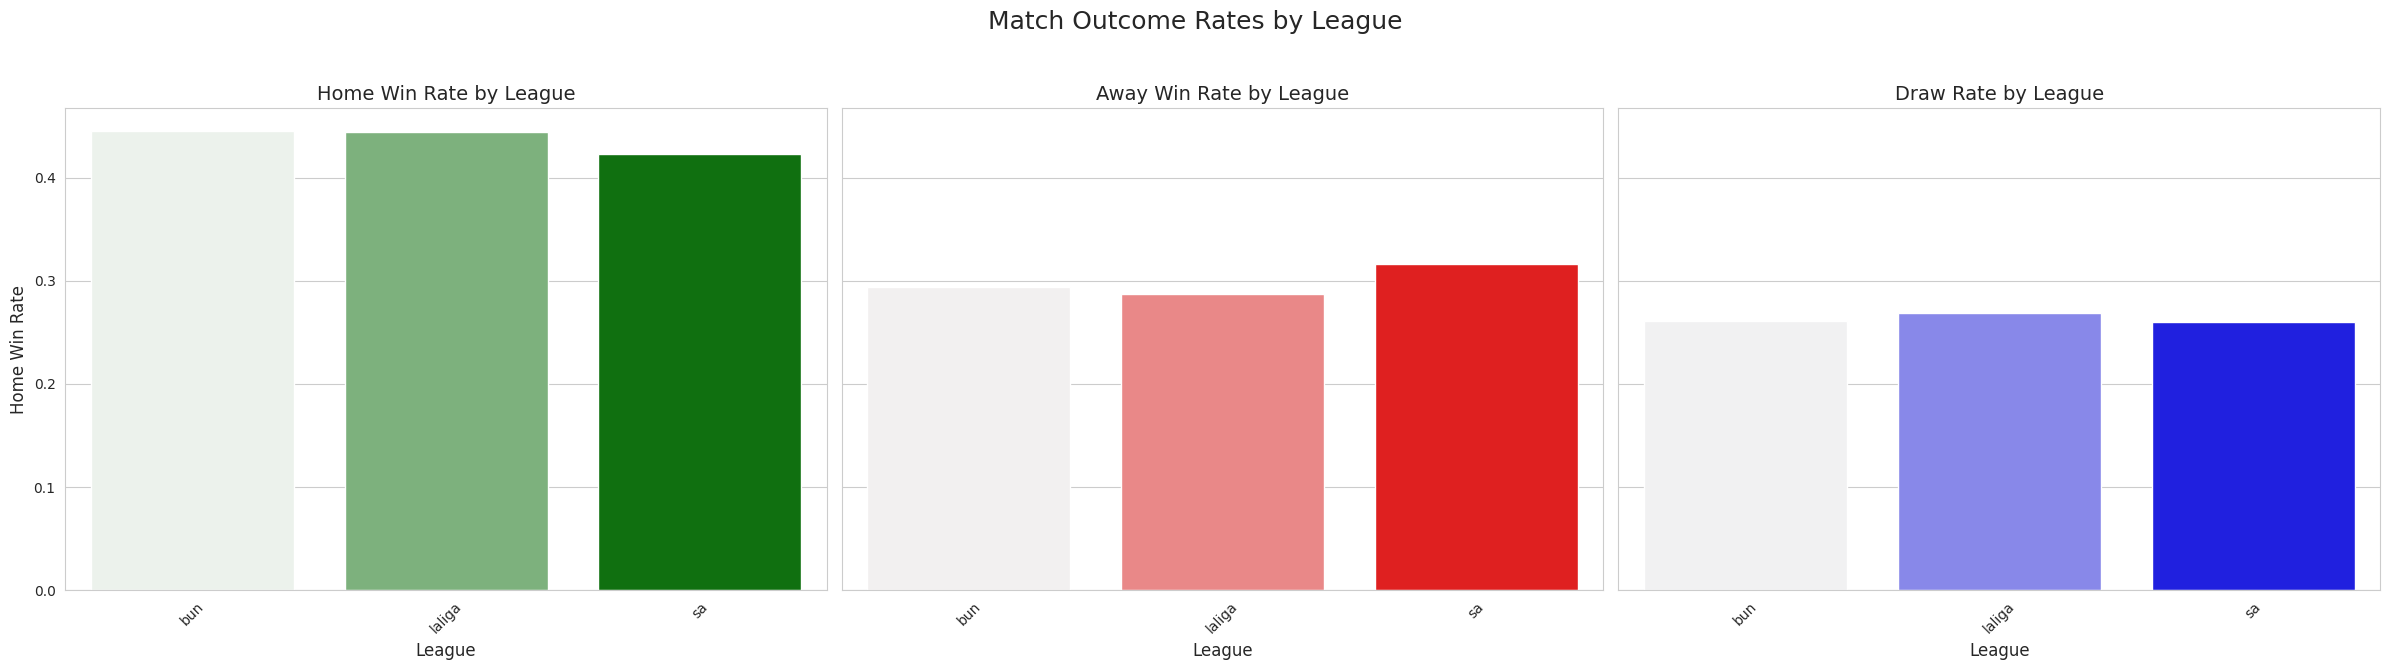

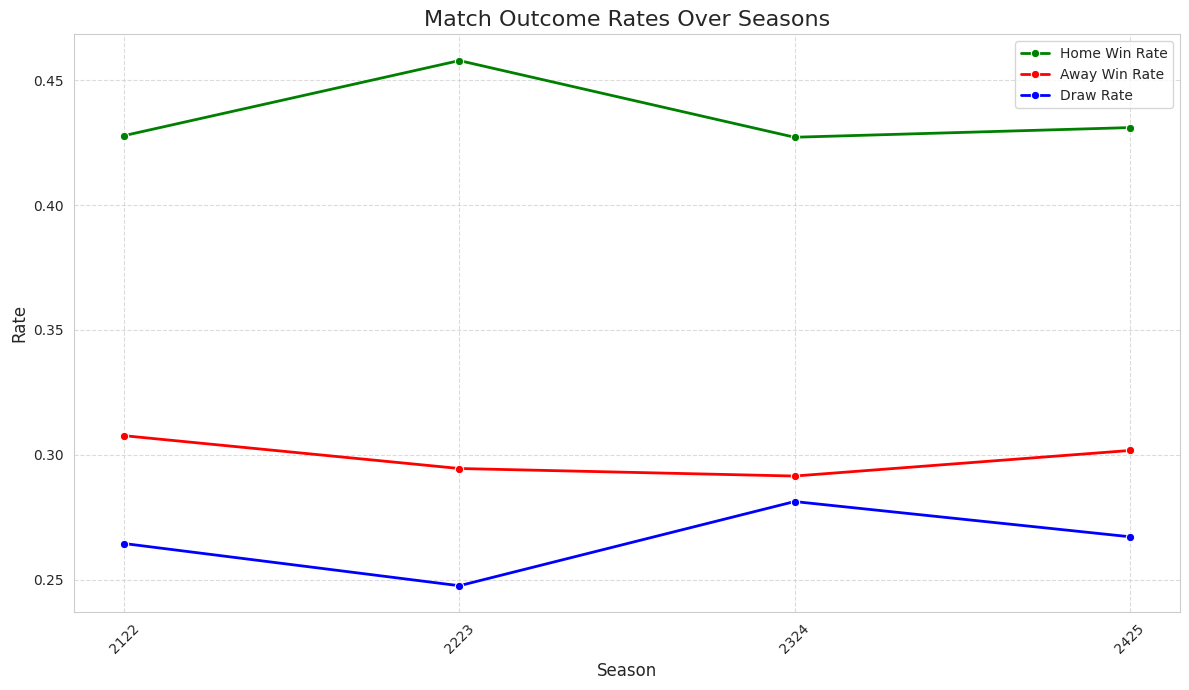

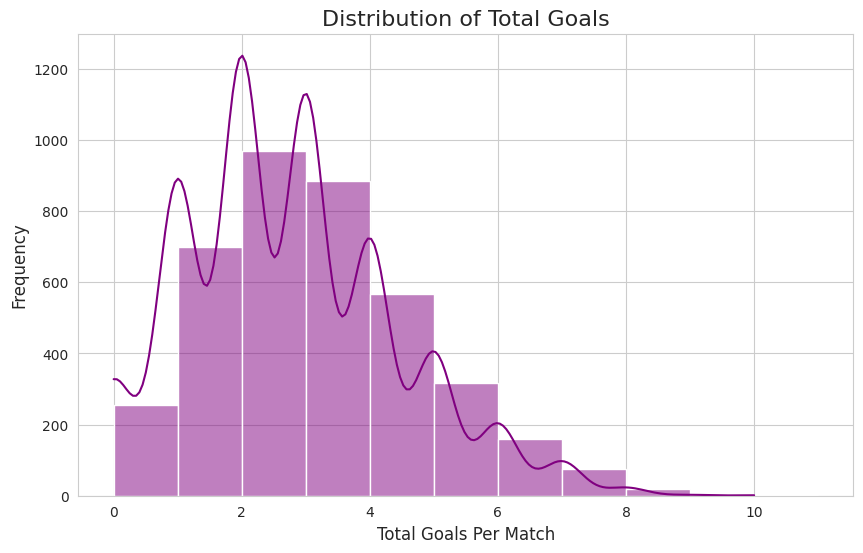

/tmp/ipython-input-903437049.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="league", y="total_goals", data=data, palette="coolwarm")


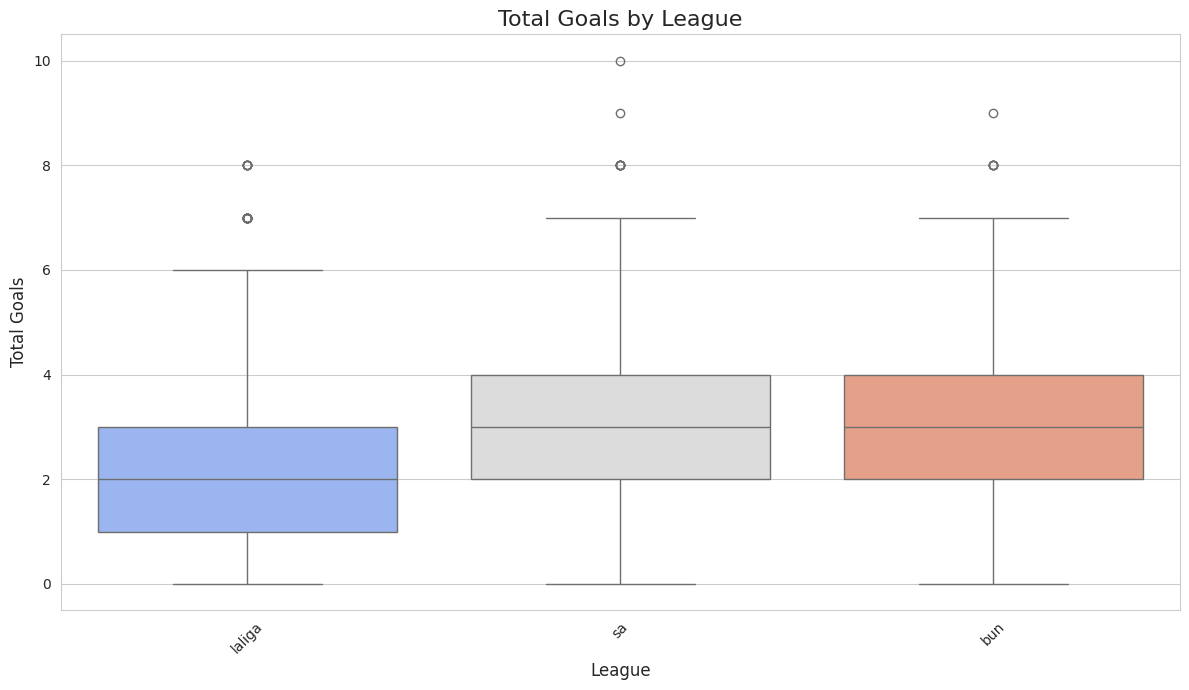

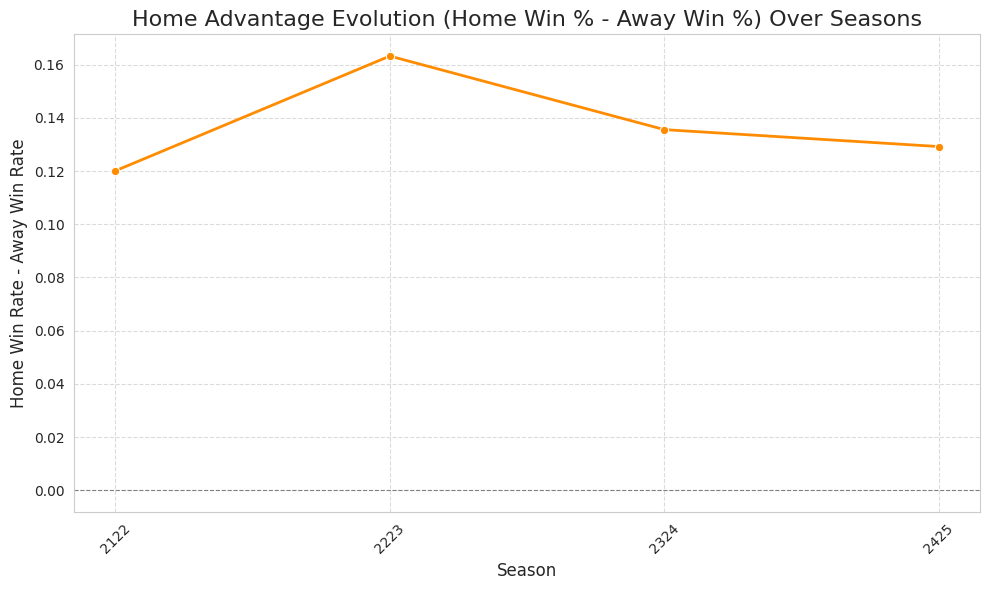

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plot style
plt.rcParams["figure.figsize"] = (18, 8)
sns.set_style("whitegrid")

# 1. Countplot for overall match results
plt.figure(figsize=(8, 6))
sns.countplot(x="result", data=data, palette="viridis")
plt.title("Distribution of Match Outcomes", fontsize=16)
plt.xlabel("Match Result (H: Home Win, D: Draw, A: Away Win)", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# Create 'away_win' and 'draw' columns for rate calculations
data["away_win"] = (data["result"] == "A").astype(int)
data["draw"] = (data["result"] == "D").astype(int)

# 2. Bar charts showing Home, Away, and Draw rates by League
league_rates = data.groupby("league")[["home_win", "away_win", "draw"]].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
fig.suptitle("Match Outcome Rates by League", fontsize=18)

sns.barplot(x="league", y="home_win", data=league_rates, ax=axes[0], palette="light:green")
axes[0].set_title("Home Win Rate by League", fontsize=14)
axes[0].set_xlabel("League", fontsize=12)
axes[0].set_ylabel("Home Win Rate", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x="league", y="away_win", data=league_rates, ax=axes[1], palette="light:red")
axes[1].set_title("Away Win Rate by League", fontsize=14)
axes[1].set_xlabel("League", fontsize=12)
axes[1].set_ylabel("Away Win Rate", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x="league", y="draw", data=league_rates, ax=axes[2], palette="light:blue")
axes[2].set_title("Draw Rate by League", fontsize=14)
axes[2].set_xlabel("League", fontsize=12)
axes[2].set_ylabel("Draw Rate", fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Line plots displaying Home Win Rate, Away Win Rate, and Draw Rate over seasons
season_rates = data.groupby("season")[["home_win", "away_win", "draw"]].mean().reset_index()
season_rates["season"] = season_rates["season"].astype(str) # Ensure season is treated as categorical for plotting

plt.figure(figsize=(12, 7))
sns.lineplot(x="season", y="home_win", data=season_rates, marker="o", label="Home Win Rate", color="green", linewidth=2)
sns.lineplot(x="season", y="away_win", data=season_rates, marker="o", label="Away Win Rate", color="red", linewidth=2)
sns.lineplot(x="season", y="draw", data=season_rates, marker="o", label="Draw Rate", color="blue", linewidth=2)

plt.title("Match Outcome Rates Over Seasons", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Rate", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Histogram of the 'total_goals' distribution
plt.figure(figsize=(10, 6))
sns.histplot(data["total_goals"], bins=range(0, data["total_goals"].max() + 2), kde=True, color="purple")
plt.title("Distribution of Total Goals", fontsize=16)
plt.xlabel("Total Goals Per Match", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 5. Boxplot comparing 'total_goals' by League
plt.figure(figsize=(12, 7))
sns.boxplot(x="league", y="total_goals", data=data, palette="coolwarm")
plt.title("Total Goals by League", fontsize=16)
plt.xlabel("League", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 6. Home Advantage evolution (Home Win % - Away Win %) over seasons
home_advantage = season_rates.copy()
home_advantage["home_advantage_diff"] = home_advantage["home_win"] - home_advantage["away_win"]

plt.figure(figsize=(10, 6))
sns.lineplot(x="season", y="home_advantage_diff", data=home_advantage, marker="o", color="darkorange", linewidth=2)
plt.title("Home Advantage Evolution (Home Win % - Away Win %) Over Seasons", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Home Win Rate - Away Win Rate", fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Reference line at 0
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated `FutureWarning` messages because `palette` was used without `hue` in several Seaborn plotting functions. To address this and ensure future compatibility, I will explicitly set `hue` to the `x` variable and `legend=False` in `sns.countplot`, `sns.barplot`, and `sns.boxplot` calls.



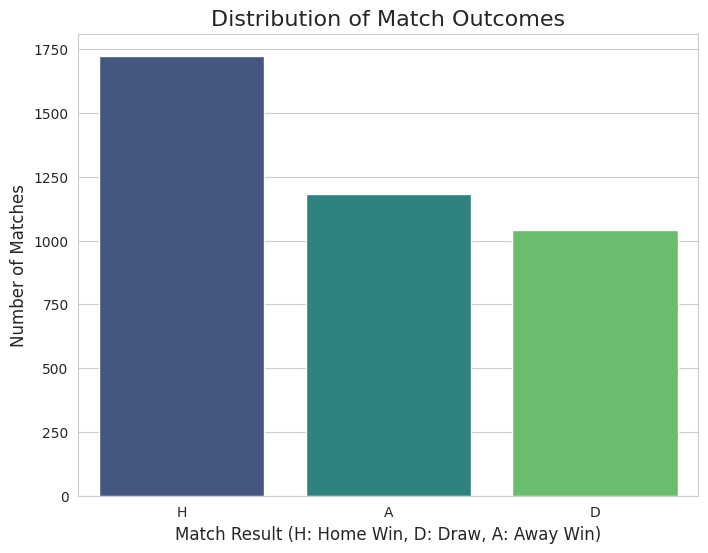

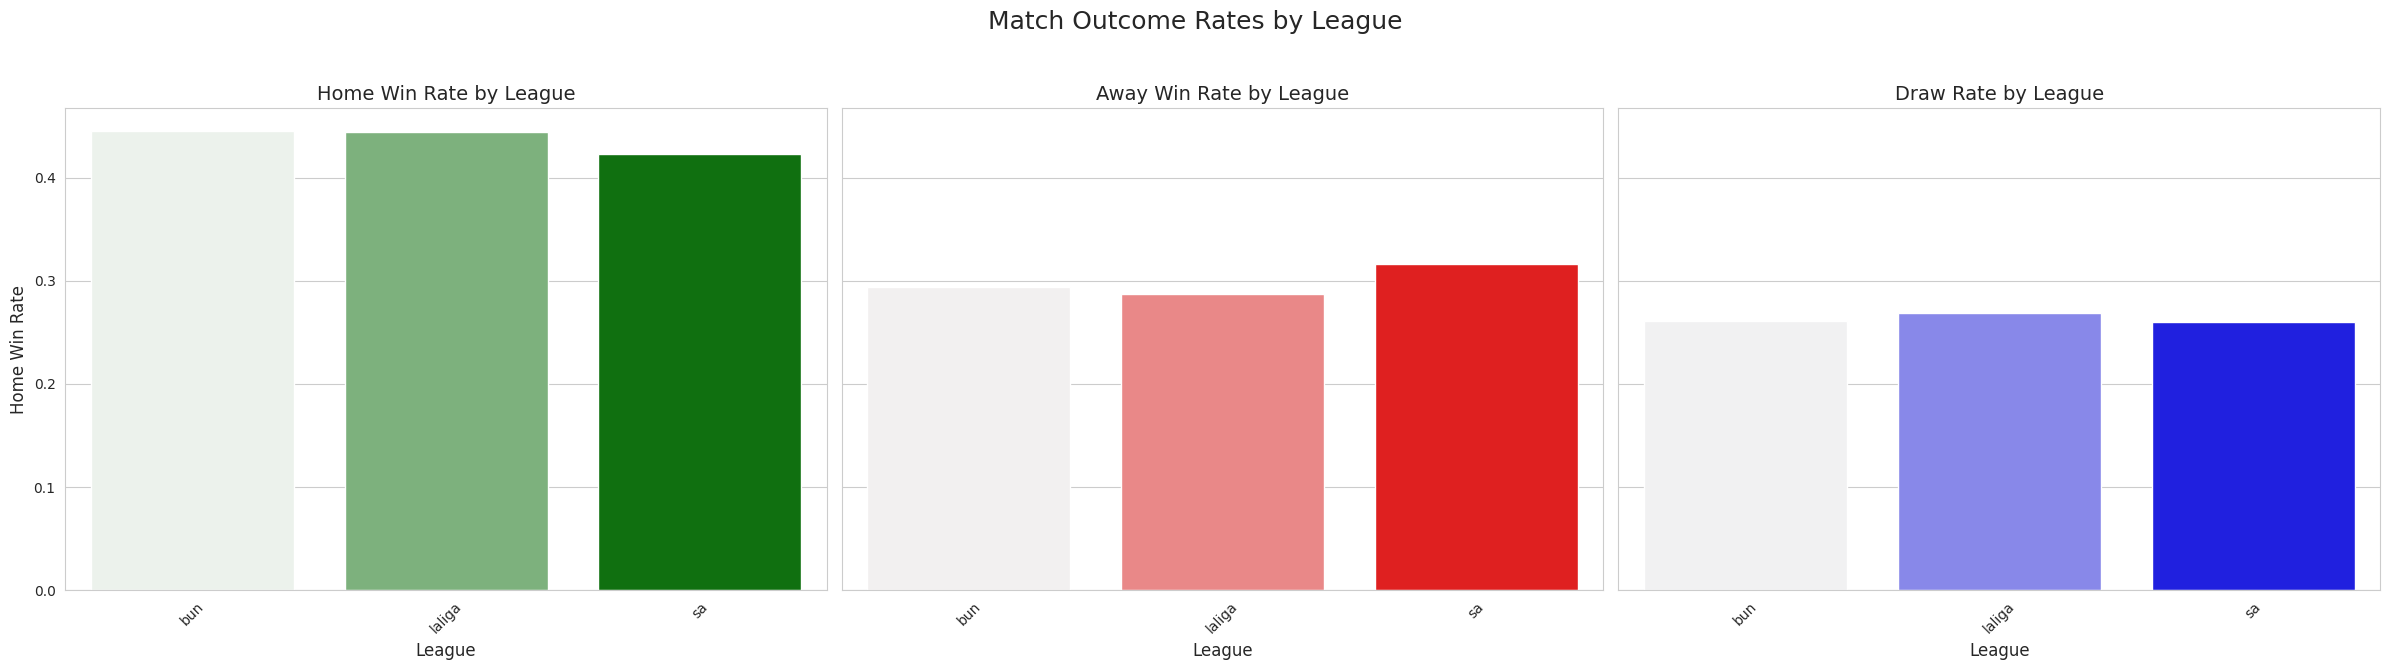

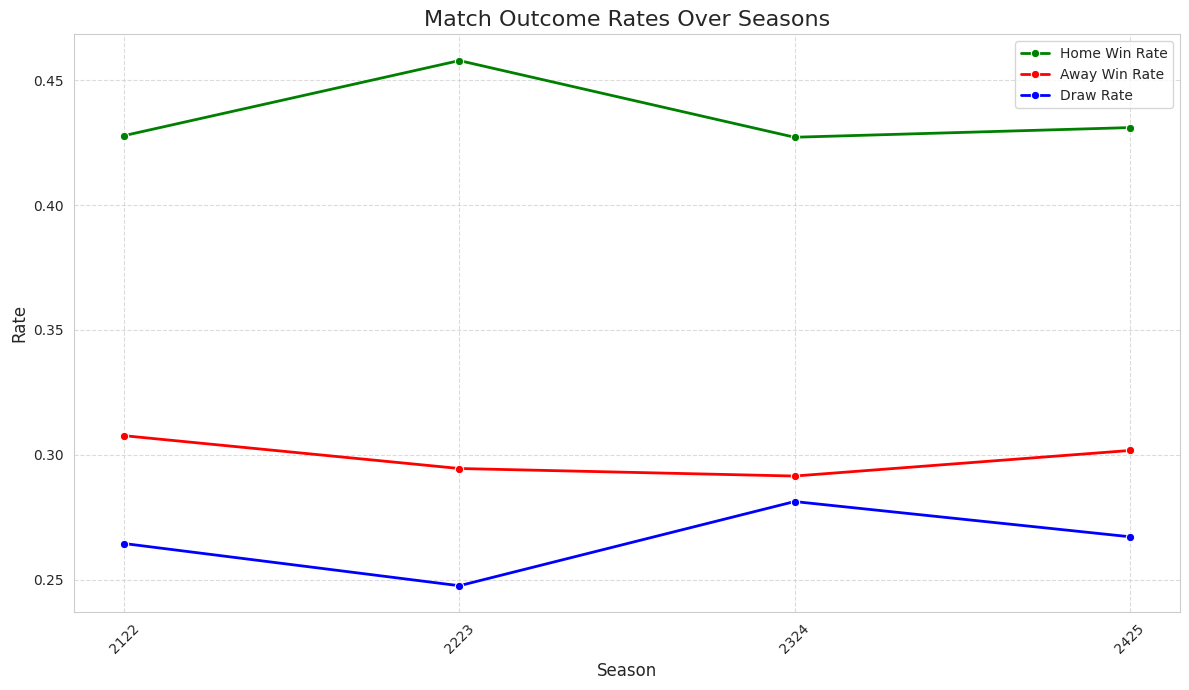

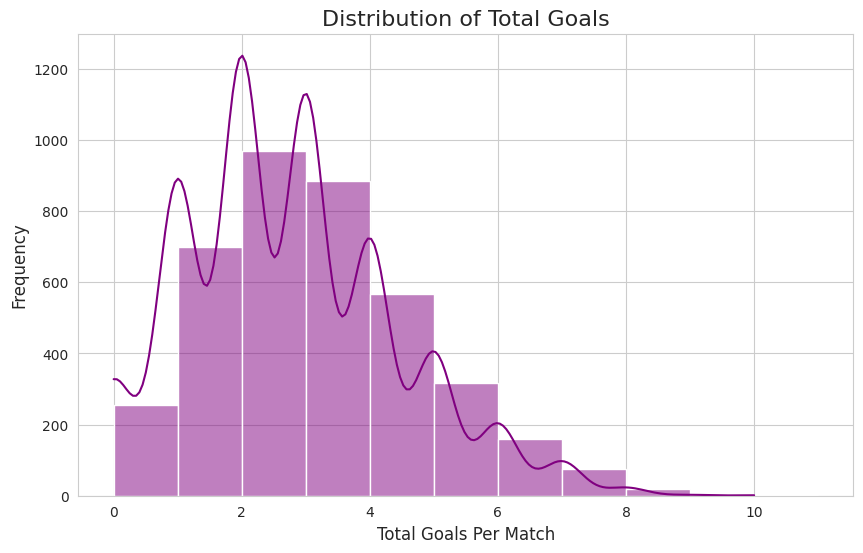

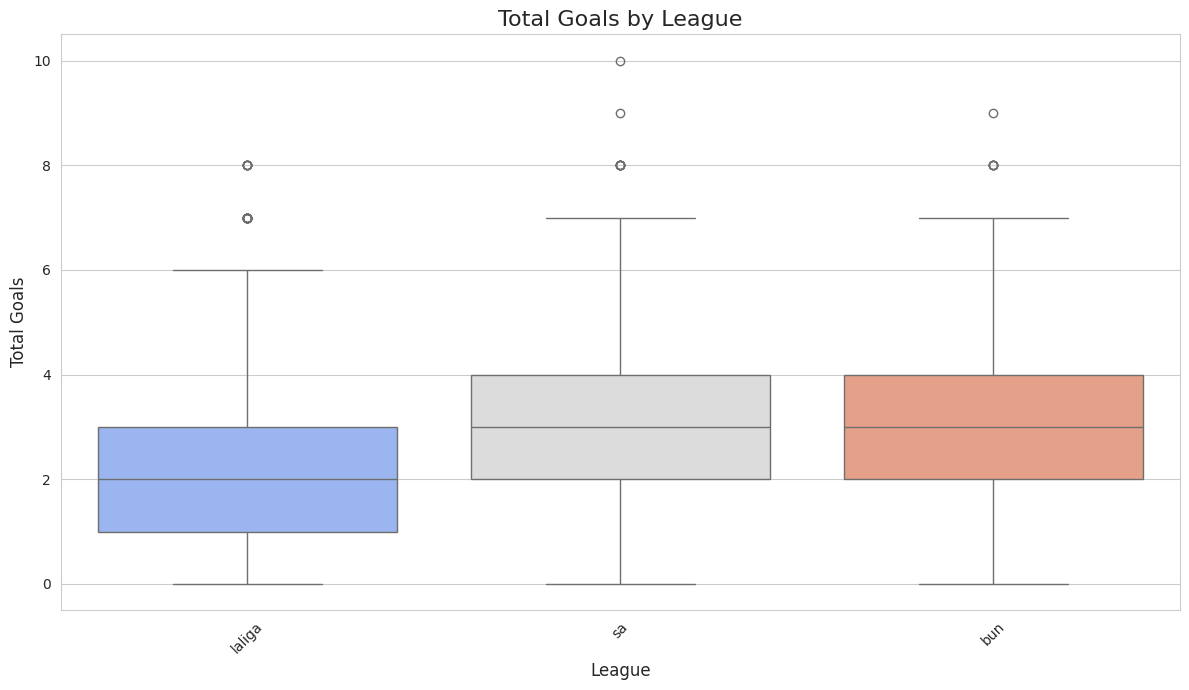

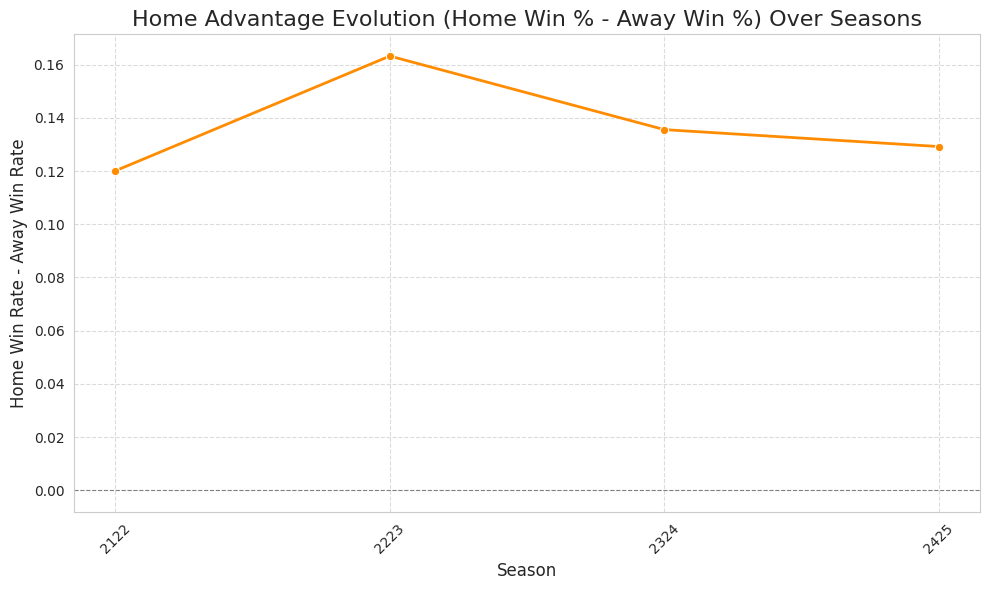

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plot style
plt.rcParams["figure.figsize"] = (18, 8)
sns.set_style("whitegrid")

# 1. Countplot for overall match results
plt.figure(figsize=(8, 6))
sns.countplot(x="result", data=data, hue="result", palette="viridis", legend=False)
plt.title("Distribution of Match Outcomes", fontsize=16)
plt.xlabel("Match Result (H: Home Win, D: Draw, A: Away Win)", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# Create 'away_win' and 'draw' columns for rate calculations
data["away_win"] = (data["result"] == "A").astype(int)
data["draw"] = (data["result"] == "D").astype(int)

# 2. Bar charts showing Home, Away, and Draw rates by League
league_rates = data.groupby("league")[["home_win", "away_win", "draw"]].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
fig.suptitle("Match Outcome Rates by League", fontsize=18)

sns.barplot(x="league", y="home_win", data=league_rates, hue="league", ax=axes[0], palette="light:green", legend=False)
axes[0].set_title("Home Win Rate by League", fontsize=14)
axes[0].set_xlabel("League", fontsize=12)
axes[0].set_ylabel("Home Win Rate", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x="league", y="away_win", data=league_rates, hue="league", ax=axes[1], palette="light:red", legend=False)
axes[1].set_title("Away Win Rate by League", fontsize=14)
axes[1].set_xlabel("League", fontsize=12)
axes[1].set_ylabel("Away Win Rate", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x="league", y="draw", data=league_rates, hue="league", ax=axes[2], palette="light:blue", legend=False)
axes[2].set_title("Draw Rate by League", fontsize=14)
axes[2].set_xlabel("League", fontsize=12)
axes[2].set_ylabel("Draw Rate", fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Line plots displaying Home Win Rate, Away Win Rate, and Draw Rate over seasons
season_rates = data.groupby("season")[["home_win", "away_win", "draw"]].mean().reset_index()
season_rates["season"] = season_rates["season"].astype(str) # Ensure season is treated as categorical for plotting

plt.figure(figsize=(12, 7))
sns.lineplot(x="season", y="home_win", data=season_rates, marker="o", label="Home Win Rate", color="green", linewidth=2)
sns.lineplot(x="season", y="away_win", data=season_rates, marker="o", label="Away Win Rate", color="red", linewidth=2)
sns.lineplot(x="season", y="draw", data=season_rates, marker="o", label="Draw Rate", color="blue", linewidth=2)

plt.title("Match Outcome Rates Over Seasons", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Rate", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Histogram of the 'total_goals' distribution
plt.figure(figsize=(10, 6))
sns.histplot(data["total_goals"], bins=range(0, data["total_goals"].max() + 2), kde=True, color="purple")
plt.title("Distribution of Total Goals", fontsize=16)
plt.xlabel("Total Goals Per Match", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 5. Boxplot comparing 'total_goals' by League
plt.figure(figsize=(12, 7))
sns.boxplot(x="league", y="total_goals", data=data, hue="league", palette="coolwarm", legend=False)
plt.title("Total Goals by League", fontsize=16)
plt.xlabel("League", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 6. Home Advantage evolution (Home Win % - Away Win %) over seasons
home_advantage = season_rates.copy()
home_advantage["home_advantage_diff"] = home_advantage["home_win"] - home_advantage["away_win"]

plt.figure(figsize=(10, 6))
sns.lineplot(x="season", y="home_advantage_diff", data=home_advantage, marker="o", color="darkorange", linewidth=2)
plt.title("Home Advantage Evolution (Home Win % - Away Win %) Over Seasons", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Home Win Rate - Away Win Rate", fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Reference line at 0
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis - Weather Effects

### Subtask:
Visualize the impact of the simulated weather conditions on match outcomes and goal scoring, including scatter plots, boxplots, and histograms.


**Reasoning**:
I need to generate the requested visualizations to explore the relationship between simulated weather conditions and match outcomes. This involves creating a categorical 'wind_speed' feature, then producing scatter plots, boxplots, and histograms as specified in the instructions, ensuring all plots have appropriate labels and titles.



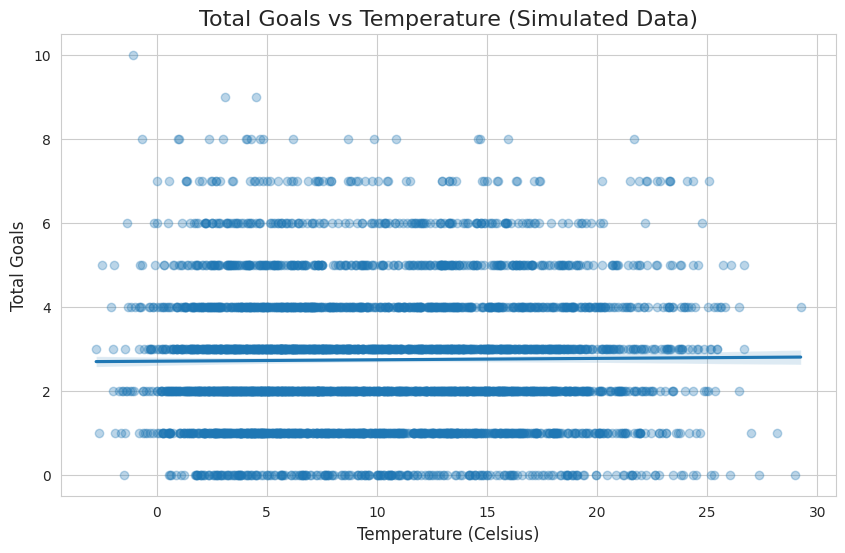

/tmp/ipython-input-320311885.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="heavy_rain", y="total_goals", data=data, palette="coolwarm")


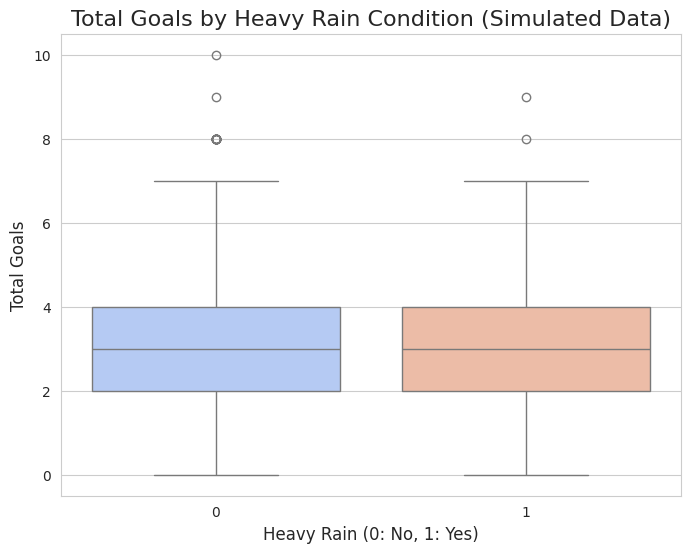

/tmp/ipython-input-320311885.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cold_weather", y="total_goals", data=data, palette="viridis")


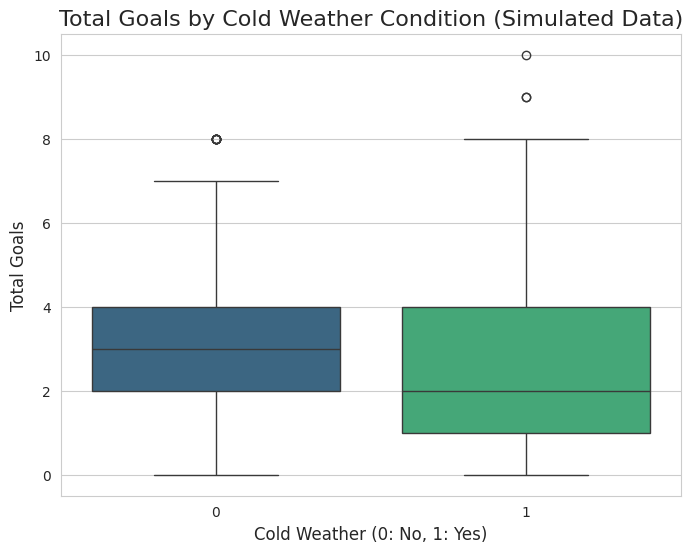

/tmp/ipython-input-320311885.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="wind_speed_category", y="total_goals", data=data, palette="plasma")


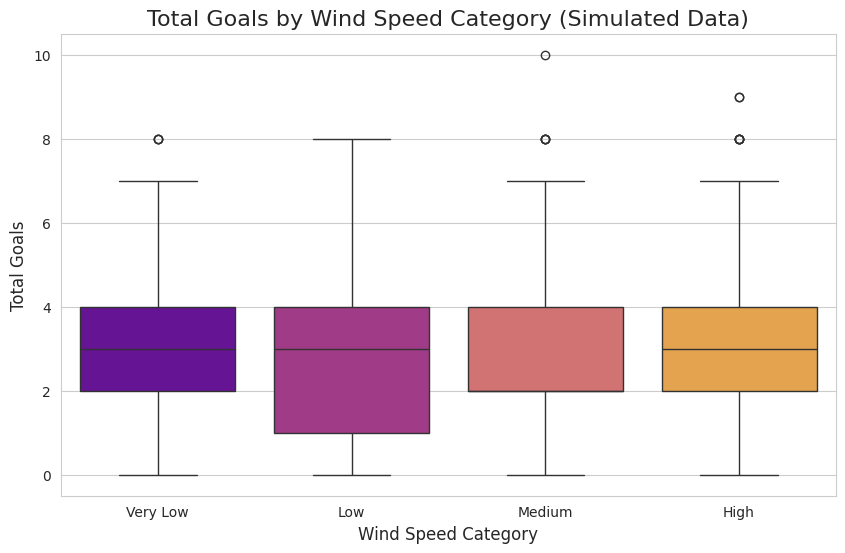

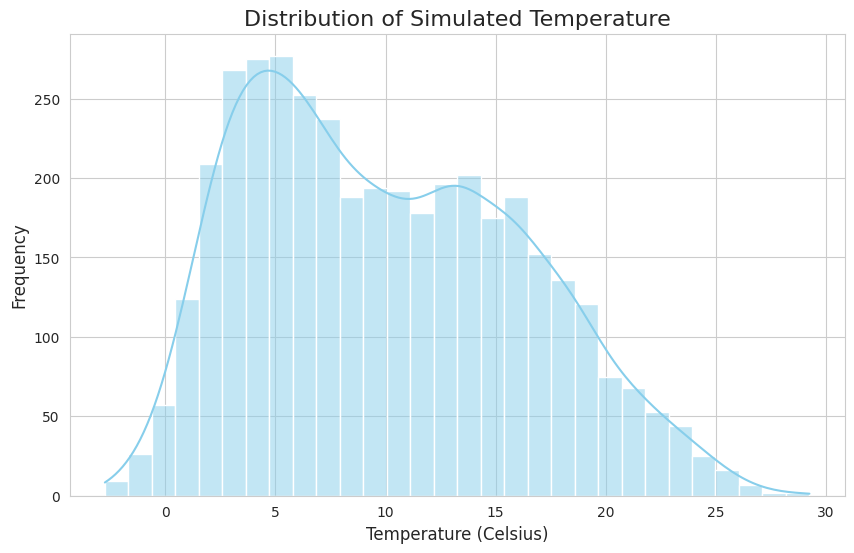

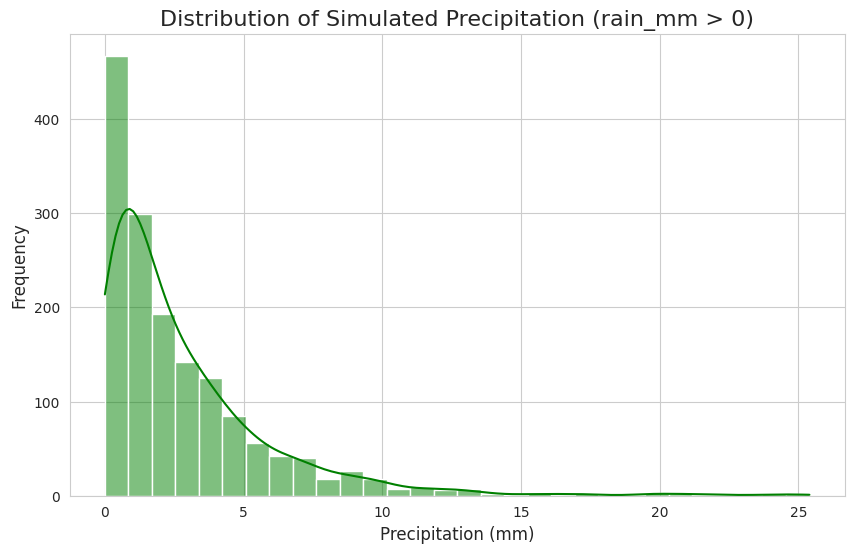

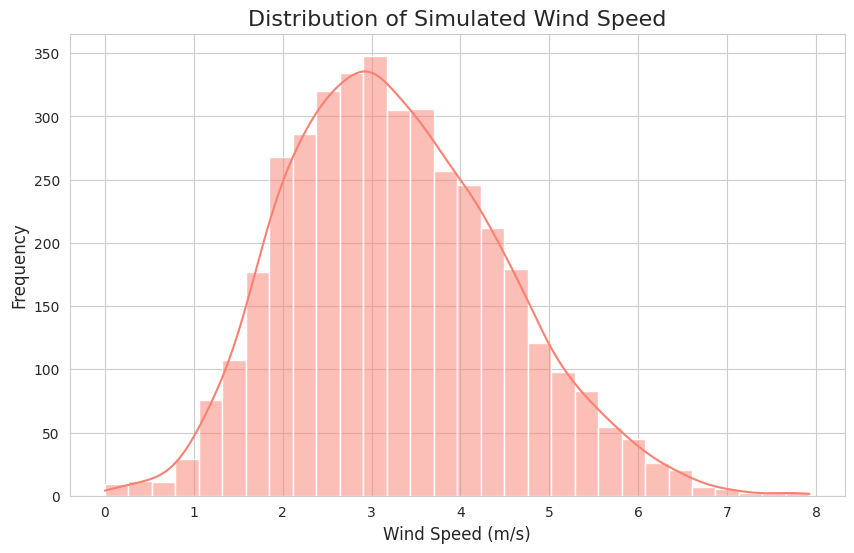

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set global plot style (already set, but for completeness)
plt.rcParams["figure.figsize"] = (18, 8)
sns.set_style("whitegrid")

# 1. Scatter plot with regression line: total_goals vs temperature
plt.figure(figsize=(10, 6))
sns.regplot(x="temperature", y="total_goals", data=data, scatter_kws={'alpha':0.3})
plt.title("Total Goals vs Temperature (Simulated Data)", fontsize=16)
plt.xlabel("Temperature (Celsius)", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 2. Boxplot: total_goals vs heavy_rain
plt.figure(figsize=(8, 6))
sns.boxplot(x="heavy_rain", y="total_goals", data=data, palette="coolwarm")
plt.title("Total Goals by Heavy Rain Condition (Simulated Data)", fontsize=16)
plt.xlabel("Heavy Rain (0: No, 1: Yes)", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 3. Boxplot: total_goals vs cold_weather
plt.figure(figsize=(8, 6))
sns.boxplot(x="cold_weather", y="total_goals", data=data, palette="viridis")
plt.title("Total Goals by Cold Weather Condition (Simulated Data)", fontsize=16)
plt.xlabel("Cold Weather (0: No, 1: Yes)", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 4. Create a categorical feature for 'wind_speed' and then a boxplot
# Using pd.qcut to divide into quartiles
data['wind_speed_category'] = pd.qcut(data['wind_speed'], q=4, labels=['Very Low', 'Low', 'Medium', 'High'], duplicates='drop')

plt.figure(figsize=(10, 6))
sns.boxplot(x="wind_speed_category", y="total_goals", data=data, palette="plasma")
plt.title("Total Goals by Wind Speed Category (Simulated Data)", fontsize=16)
plt.xlabel("Wind Speed Category", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 5. Histogram for 'temperature' distribution
plt.figure(figsize=(10, 6))
sns.histplot(data["temperature"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Simulated Temperature", fontsize=16)
plt.xlabel("Temperature (Celsius)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 6. Histogram for 'rain_mm' (precipitation) distribution
plt.figure(figsize=(10, 6))
sns.histplot(data[data['rain_mm'] > 0]["rain_mm"], bins=30, kde=True, color="green") # Only show non-zero rain for better visualization
plt.title("Distribution of Simulated Precipitation (rain_mm > 0)", fontsize=16)
plt.xlabel("Precipitation (mm)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 7. Histogram for 'wind_speed' distribution
plt.figure(figsize=(10, 6))
sns.histplot(data["wind_speed"], bins=30, kde=True, color="salmon")
plt.title("Distribution of Simulated Wind Speed", fontsize=16)
plt.xlabel("Wind Speed (m/s)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

**Reasoning**:
The previous code generated `FutureWarning` messages due to `palette` being used without `hue` in `sns.boxplot`. To resolve this and ensure compatibility, I will modify the `sns.boxplot` calls to explicitly set `hue` to the `x` variable and `legend=False`.



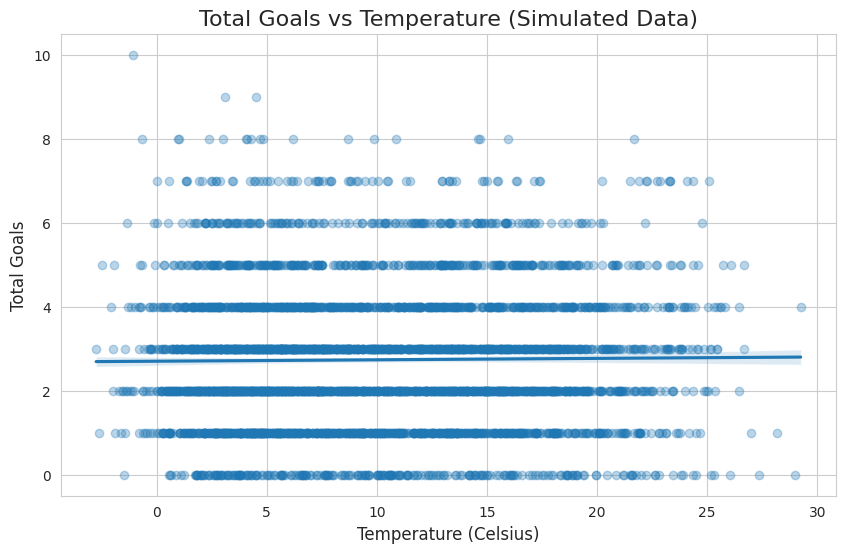

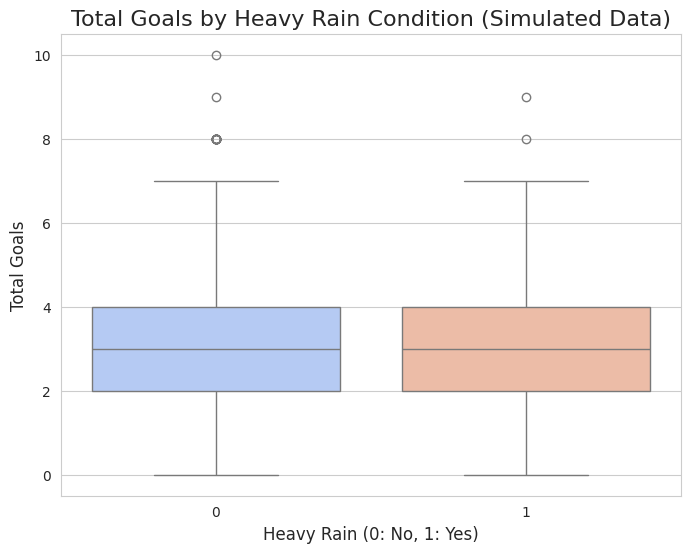

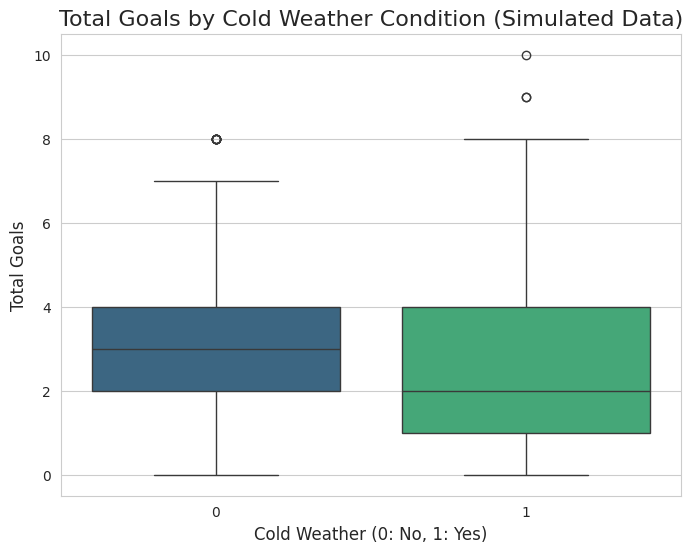

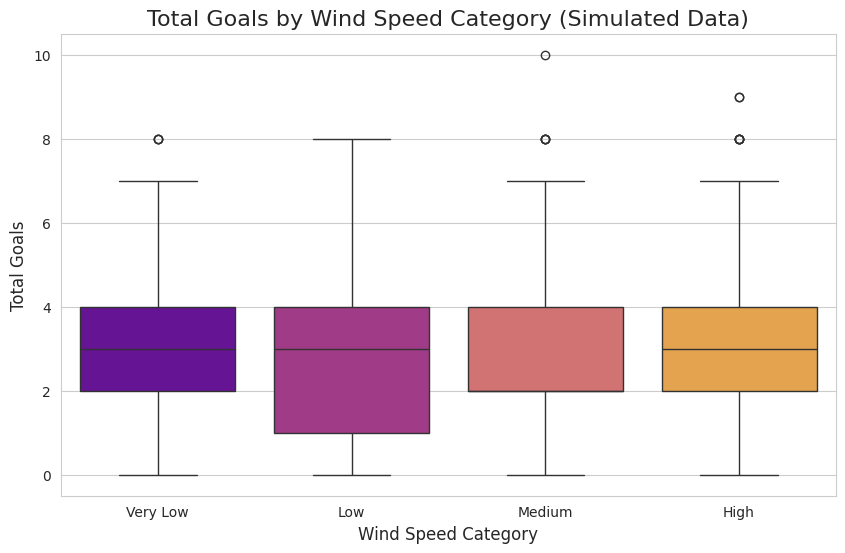

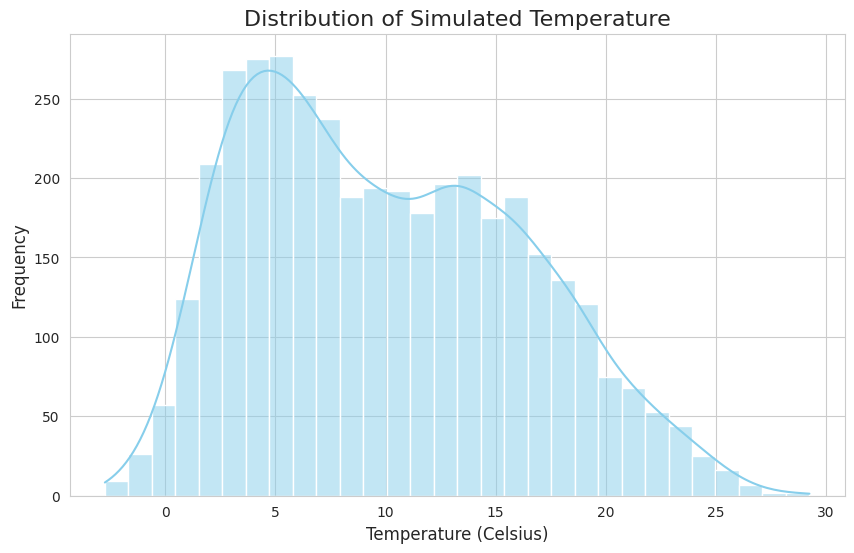

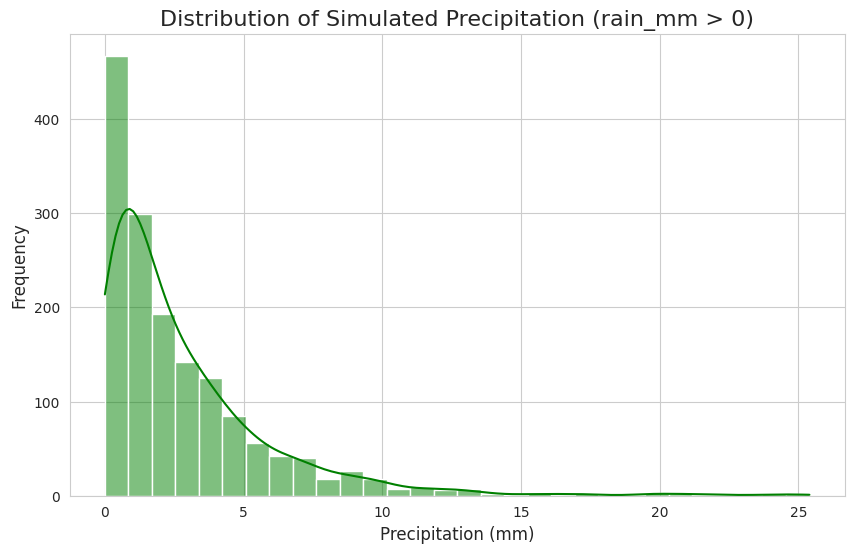

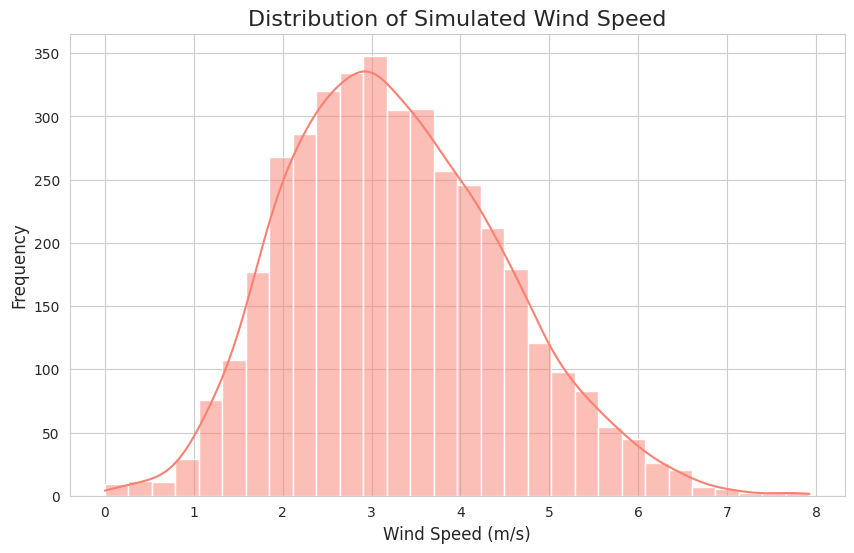

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set global plot style (already set, but for completeness)
plt.rcParams["figure.figsize"] = (18, 8)
sns.set_style("whitegrid")

# 1. Scatter plot with regression line: total_goals vs temperature
plt.figure(figsize=(10, 6))
sns.regplot(x="temperature", y="total_goals", data=data, scatter_kws={'alpha':0.3})
plt.title("Total Goals vs Temperature (Simulated Data)", fontsize=16)
plt.xlabel("Temperature (Celsius)", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 2. Boxplot: total_goals vs heavy_rain
plt.figure(figsize=(8, 6))
sns.boxplot(x="heavy_rain", y="total_goals", data=data, hue="heavy_rain", palette="coolwarm", legend=False)
plt.title("Total Goals by Heavy Rain Condition (Simulated Data)", fontsize=16)
plt.xlabel("Heavy Rain (0: No, 1: Yes)", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 3. Boxplot: total_goals vs cold_weather
plt.figure(figsize=(8, 6))
sns.boxplot(x="cold_weather", y="total_goals", data=data, hue="cold_weather", palette="viridis", legend=False)
plt.title("Total Goals by Cold Weather Condition (Simulated Data)", fontsize=16)
plt.xlabel("Cold Weather (0: No, 1: Yes)", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 4. Create a categorical feature for 'wind_speed' and then a boxplot
# Using pd.qcut to divide into quartiles
data['wind_speed_category'] = pd.qcut(data['wind_speed'], q=4, labels=['Very Low', 'Low', 'Medium', 'High'], duplicates='drop')

plt.figure(figsize=(10, 6))
sns.boxplot(x="wind_speed_category", y="total_goals", data=data, hue="wind_speed_category", palette="plasma", legend=False)
plt.title("Total Goals by Wind Speed Category (Simulated Data)", fontsize=16)
plt.xlabel("Wind Speed Category", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 5. Histogram for 'temperature' distribution
plt.figure(figsize=(10, 6))
sns.histplot(data["temperature"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Simulated Temperature", fontsize=16)
plt.xlabel("Temperature (Celsius)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 6. Histogram for 'rain_mm' (precipitation) distribution
plt.figure(figsize=(10, 6))
sns.histplot(data[data['rain_mm'] > 0]["rain_mm"], bins=30, kde=True, color="green") # Only show non-zero rain for better visualization
plt.title("Distribution of Simulated Precipitation (rain_mm > 0)", fontsize=16)
plt.xlabel("Precipitation (mm)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 7. Histogram for 'wind_speed' distribution
plt.figure(figsize=(10, 6))
sns.histplot(data["wind_speed"], bins=30, kde=True, color="salmon")
plt.title("Distribution of Simulated Wind Speed", fontsize=16)
plt.xlabel("Wind Speed (m/s)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## Exploratory Data Analysis - Other Factors & Correlations

### Subtask:
Analyze other contextual factors and their interrelationships, including histograms for rest days, boxplots comparing rest days to match outcomes, a barplot for home win rate against the 'playing_leader' proxy, and a heatmap of the correlation matrix between selected features.


**Reasoning**:
I need to generate the specified visualizations and the correlation heatmap to analyze the impact of rest days, playing leader proxy, and other contextual factors on match outcomes. This includes histograms, boxplots, a barplot, and a heatmap as requested in the instructions.



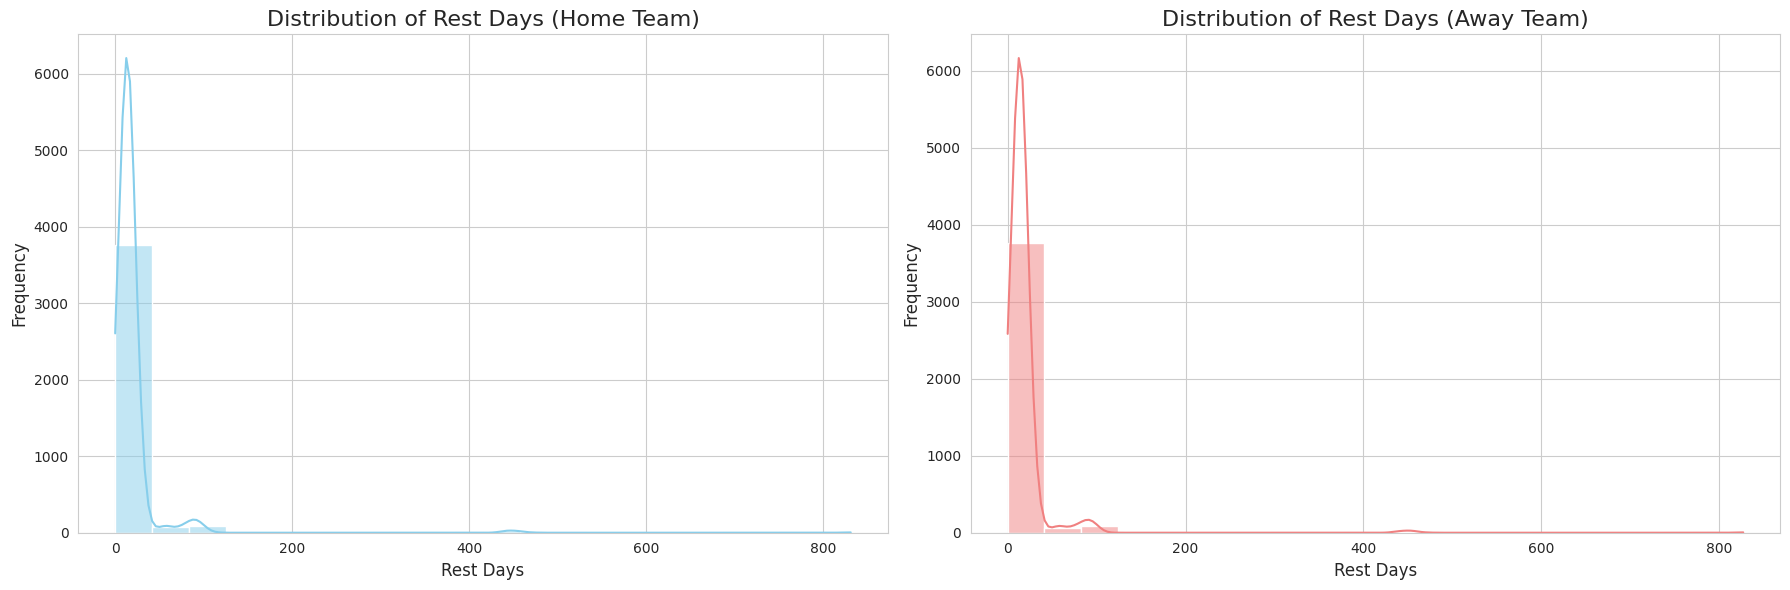

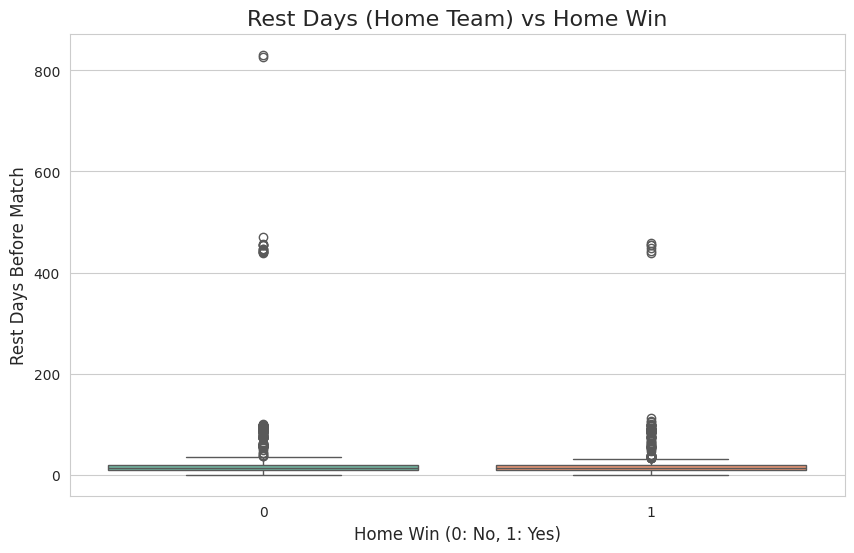

/tmp/ipython-input-3134303477.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="rest_days_home", y="total_goals", data=data, palette="muted")


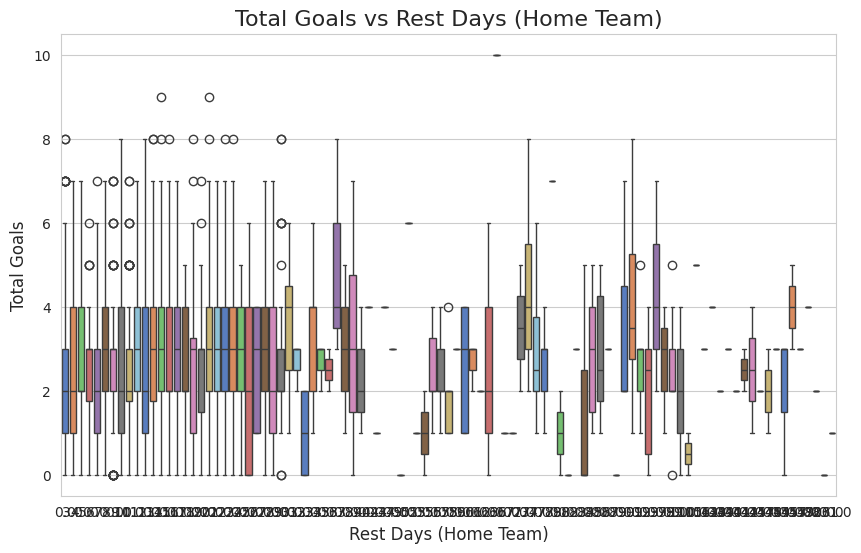

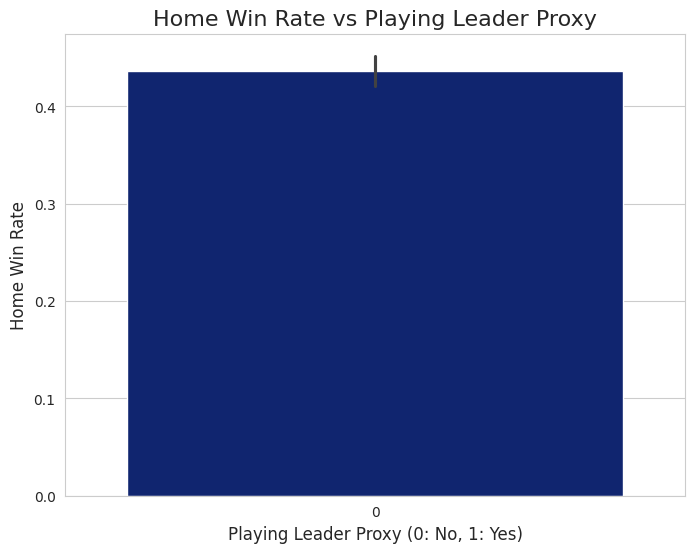

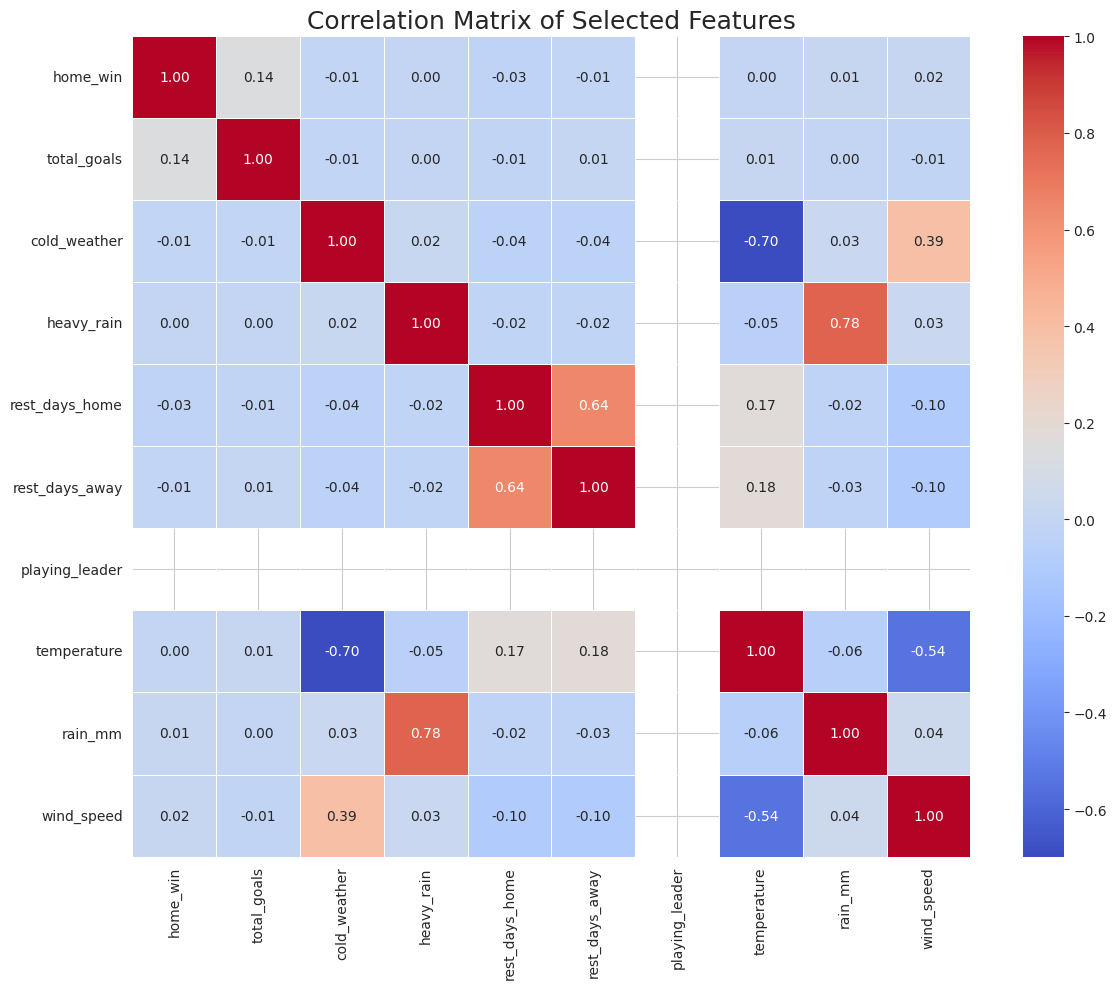

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plot style (already set, but for completeness)
plt.rcParams["figure.figsize"] = (18, 8)
sns.set_style("whitegrid")

# 1. Histograms for the distribution of 'rest_days_home' and 'rest_days_away'
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(data["rest_days_home"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Rest Days (Home Team)", fontsize=16)
plt.xlabel("Rest Days", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.subplot(1, 2, 2)
sns.histplot(data["rest_days_away"], bins=20, kde=True, color="lightcoral")
plt.title("Distribution of Rest Days (Away Team)", fontsize=16)
plt.xlabel("Rest Days", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 2. Boxplot: home_win vs rest_days_home
plt.figure(figsize=(10, 6))
sns.boxplot(x="home_win", y="rest_days_home", data=data, hue="home_win", palette="Set2", legend=False)
plt.title("Rest Days (Home Team) vs Home Win", fontsize=16)
plt.xlabel("Home Win (0: No, 1: Yes)", fontsize=12)
plt.ylabel("Rest Days Before Match", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 3. Boxplot: total_goals vs rest_days_home
plt.figure(figsize=(10, 6))
sns.boxplot(x="rest_days_home", y="total_goals", data=data, palette="muted")
plt.title("Total Goals vs Rest Days (Home Team)", fontsize=16)
plt.xlabel("Rest Days (Home Team)", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 4. Barplot for 'home_win' rate against 'playing_leader'
plt.figure(figsize=(8, 6))
sns.barplot(x="playing_leader", y="home_win", data=data, hue="playing_leader", palette="dark", legend=False)
plt.title("Home Win Rate vs Playing Leader Proxy", fontsize=16)
plt.xlabel("Playing Leader Proxy (0: No, 1: Yes)", fontsize=12)
plt.ylabel("Home Win Rate", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 5. Select a set of relevant numerical features and target variables for correlation analysis.
features_corr = [
    "home_win",
    "total_goals",
    "cold_weather",
    "heavy_rain",
    "rest_days_home",
    "rest_days_away",
    "playing_leader",
    "temperature",
    "rain_mm",
    "wind_speed"
]

# 6. Calculate the correlation matrix
correlation_matrix = data[features_corr].corr()

# 7. Create a heatmap of this correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Selected Features", fontsize=18)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` for `sns.boxplot` because `palette` was used without `hue` when `rest_days_home` is on the x-axis. To resolve this and ensure compatibility, I will explicitly set `hue` to the `x` variable (`rest_days_home`) and `legend=False` in that specific `sns.boxplot` call.



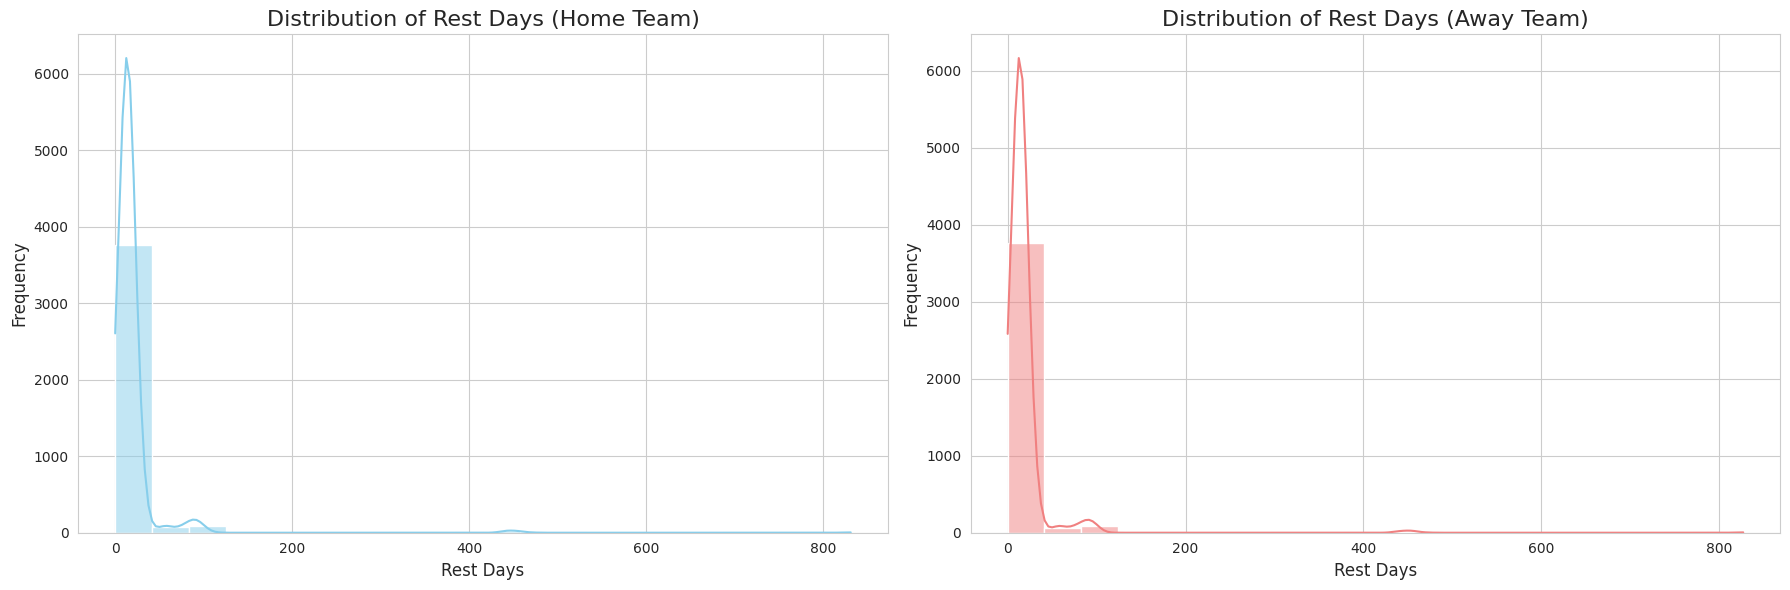

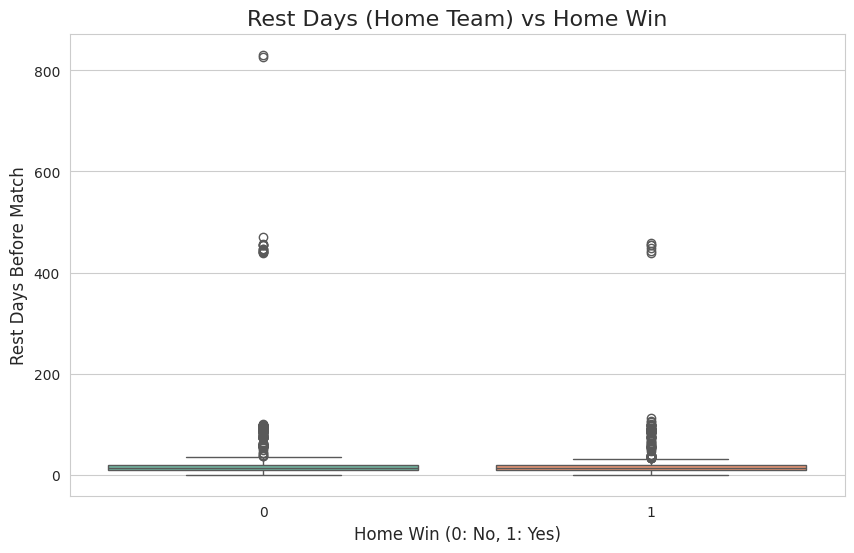

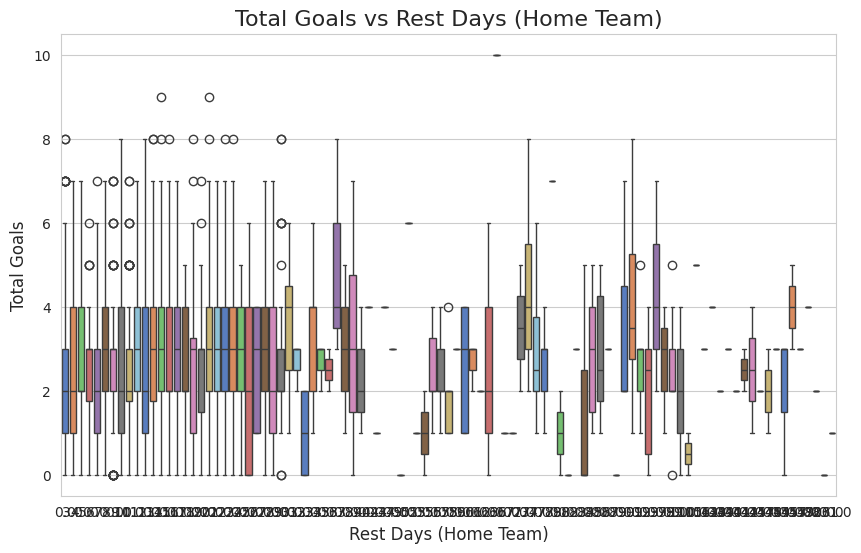

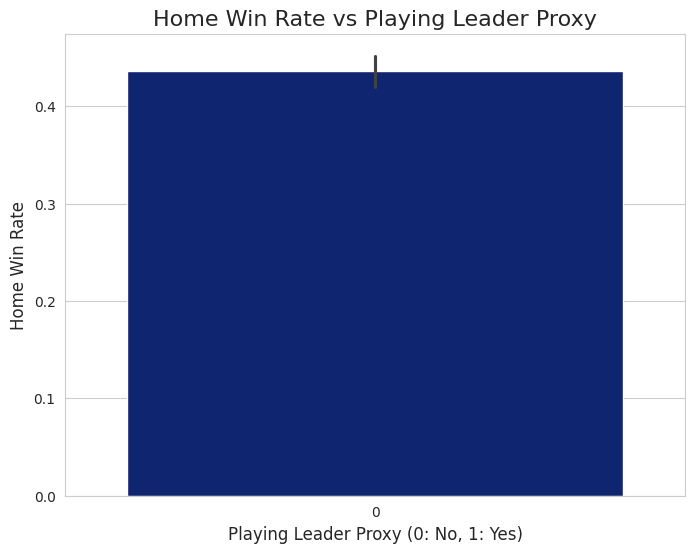

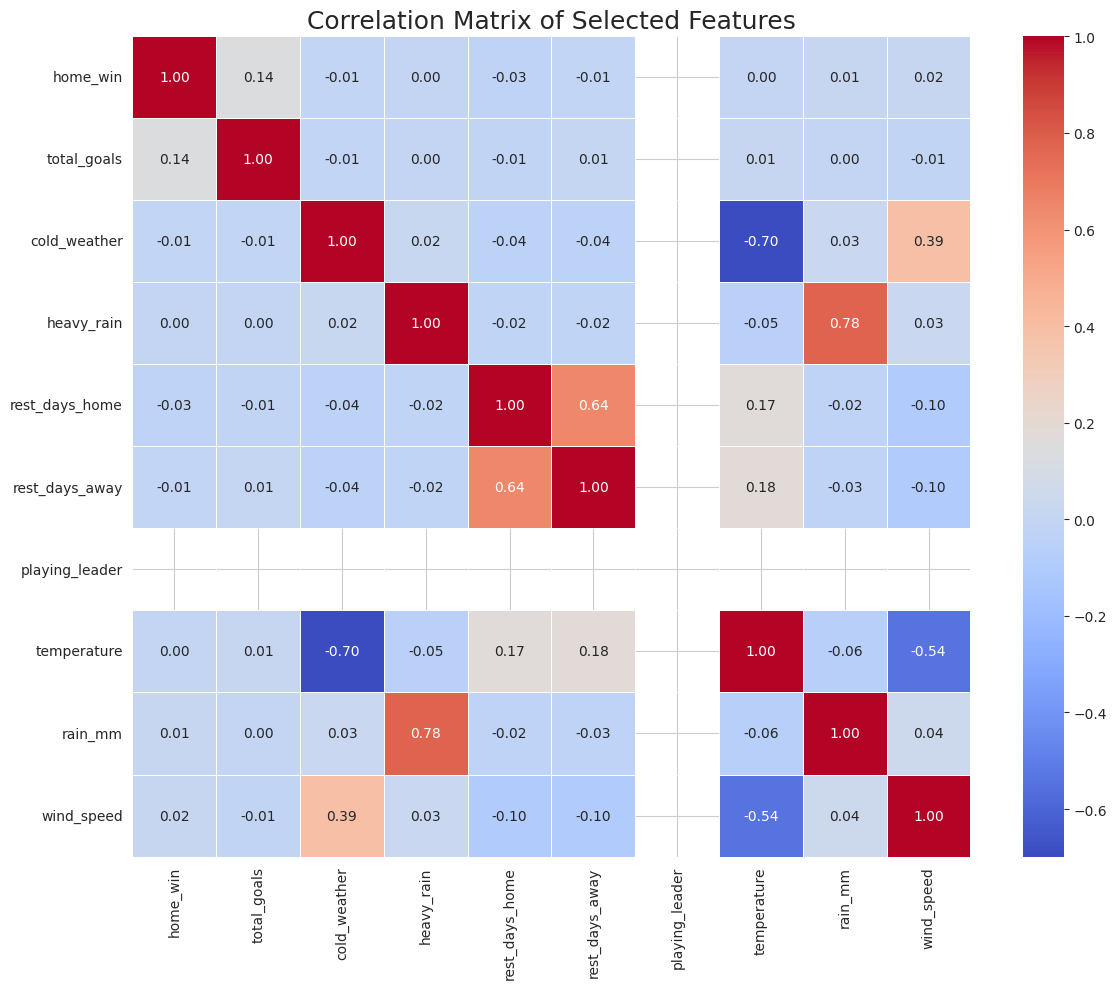

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plot style (already set, but for completeness)
plt.rcParams["figure.figsize"] = (18, 8)
sns.set_style("whitegrid")

# 1. Histograms for the distribution of 'rest_days_home' and 'rest_days_away'
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(data["rest_days_home"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Rest Days (Home Team)", fontsize=16)
plt.xlabel("Rest Days", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.subplot(1, 2, 2)
sns.histplot(data["rest_days_away"], bins=20, kde=True, color="lightcoral")
plt.title("Distribution of Rest Days (Away Team)", fontsize=16)
plt.xlabel("Rest Days", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 2. Boxplot: home_win vs rest_days_home
plt.figure(figsize=(10, 6))
sns.boxplot(x="home_win", y="rest_days_home", data=data, hue="home_win", palette="Set2", legend=False)
plt.title("Rest Days (Home Team) vs Home Win", fontsize=16)
plt.xlabel("Home Win (0: No, 1: Yes)", fontsize=12)
plt.ylabel("Rest Days Before Match", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 3. Boxplot: total_goals vs rest_days_home
plt.figure(figsize=(10, 6))
sns.boxplot(x="rest_days_home", y="total_goals", data=data, hue="rest_days_home", palette="muted", legend=False)
plt.title("Total Goals vs Rest Days (Home Team)", fontsize=16)
plt.xlabel("Rest Days (Home Team)", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 4. Barplot for 'home_win' rate against 'playing_leader'
plt.figure(figsize=(8, 6))
sns.barplot(x="playing_leader", y="home_win", data=data, hue="playing_leader", palette="dark", legend=False)
plt.title("Home Win Rate vs Playing Leader Proxy", fontsize=16)
plt.xlabel("Playing Leader Proxy (0: No, 1: Yes)", fontsize=12)
plt.ylabel("Home Win Rate", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# 5. Select a set of relevant numerical features and target variables for correlation analysis.
features_corr = [
    "home_win",
    "total_goals",
    "cold_weather",
    "heavy_rain",
    "rest_days_home",
    "rest_days_away",
    "playing_leader",
    "temperature",
    "rain_mm",
    "wind_speed"
]

# 6. Calculate the correlation matrix
correlation_matrix = data[features_corr].corr()

# 7. Create a heatmap of this correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Selected Features", fontsize=18)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


## Hypothesis Testing - Home Advantage

### Subtask:
Perform statistical hypothesis tests to formally assess the significance of home advantage. Formulate null (H0) and alternative (H1) hypotheses, for example: H0: The proportion of home wins is 50%, H1: It is not 50% (using a Z-test or Chi-square). Also, test if there are significant differences in home win rates across different leagues using ANOVA. Clearly state the hypotheses and interpret the p-values for each test.


**Reasoning**:
The subtask requires performing two statistical hypothesis tests: a one-sample Z-test for proportions to assess overall home advantage and a one-way ANOVA test to compare home win rates across different leagues. This code block will import the necessary statistical functions, calculate the required statistics, and present the results with interpretations.



In [17]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import f_oneway
import pandas as pd

# --- Test 1: Overall Home Advantage (Proportion of Home Wins) ---

# Hypotheses
h0_overall_home_win = "H0: The proportion of home wins is 50% (P = 0.5)"
h1_overall_home_win = "H1: The proportion of home wins is not 50% (P != 0.5)"

print("\n--- Test 1: Overall Home Advantage (Proportion of Home Wins) ---")
print("Null Hypothesis (H0):", h0_overall_home_win)
print("Alternative Hypothesis (H1):", h1_overall_home_win)

# Calculate total home wins and total matches
total_home_wins = data["home_win"].sum()
total_matches = len(data)

# Perform one-sample Z-test for proportions
stat_z, pval_z = proportions_ztest(count=total_home_wins, nobs=total_matches, value=0.5)

print(f"\nTotal Matches: {total_matches}")
print(f"Total Home Wins: {total_home_wins}")
print(f"Observed Home Win Rate: {total_home_wins/total_matches:.2%}")
print(f"Z-statistic: {stat_z:.4f}")
print(f"P-value: {pval_z:.4f}")

alpha = 0.05
if pval_z < alpha:
    print(f"Conclusion: Since the p-value ({pval_z:.4f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("There is statistically significant evidence that the proportion of home wins is not 50%.")
else:
    print(f"Conclusion: Since the p-value ({pval_z:.4f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant evidence that the proportion of home wins is different from 50%.")


# --- Test 2: Home Advantage across Leagues (Differences in Home Win Rates) ---

# Hypotheses
h0_league_home_win = "H0: The mean home win rates are the same across all leagues."
h1_league_home_win = "H1: At least one league's mean home win rate is different from the others."

print("\n--- Test 2: Home Advantage across Leagues (Differences in Home Win Rates) ---")
print("Null Hypothesis (H0):", h0_league_home_win)
print("Alternative Hypothesis (H1):", h1_league_home_win)

# Prepare data for ANOVA: list of home win rates for each league
league_home_wins = [data['home_win'][data['league'] == league].values for league in data['league'].unique()]

# Perform one-way ANOVA test
stat_f, pval_f = f_oneway(*league_home_wins)

print(f"\nF-statistic: {stat_f:.4f}")
print(f"P-value: {pval_f:.4f}")

if pval_f < alpha:
    print(f"Conclusion: Since the p-value ({pval_f:.4f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("There is statistically significant evidence that the mean home win rates are different across at least some leagues.")
else:
    print(f"Conclusion: Since the p-value ({pval_f:.4f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant evidence that the mean home win rates are different across leagues.")

# Display mean home win rates by league for context
print("\nMean Home Win Rates by League:")
print(data.groupby('league')['home_win'].mean().apply(lambda x: f'{x:.2%}'))


--- Test 1: Overall Home Advantage (Proportion of Home Wins) ---
Null Hypothesis (H0): H0: The proportion of home wins is 50% (P = 0.5)
Alternative Hypothesis (H1): H1: The proportion of home wins is not 50% (P != 0.5)

Total Matches: 3948
Total Home Wins: 1724
Observed Home Win Rate: 43.67%
Z-statistic: -8.0222
P-value: 0.0000
Conclusion: Since the p-value (0.0000) is less than alpha (0.05), we reject the null hypothesis.
There is statistically significant evidence that the proportion of home wins is not 50%.

--- Test 2: Home Advantage across Leagues (Differences in Home Win Rates) ---
Null Hypothesis (H0): H0: The mean home win rates are the same across all leagues.
Alternative Hypothesis (H1): H1: At least one league's mean home win rate is different from the others.

F-statistic: 0.8385
P-value: 0.4324
Conclusion: Since the p-value (0.4324) is greater than alpha (0.05), we fail to reject the null hypothesis.
There is no statistically significant evidence that the mean home win ra

## Hypothesis Testing - Weather Effects on Goals

### Subtask:
Conduct hypothesis tests to investigate if cold weather and heavy rain significantly impact the total number of goals scored. For example: H0: The mean total goals in cold weather equals the mean total goals in non-cold weather, H1: They are different (using an independent samples t-test). Perform a similar test for heavy rain vs. no heavy rain. Clearly state the hypotheses and interpret the p-values.


**Reasoning**:
I need to perform two independent samples t-tests, one for cold weather and one for heavy rain, to assess their impact on total goals as specified in the subtask. This involves filtering the data, applying the t-test, and interpreting the results for each condition.



In [18]:
from scipy.stats import ttest_ind

alpha = 0.05

# --- Test 1: Impact of Cold Weather on Total Goals ---

print("\n--- Test 1: Impact of Cold Weather on Total Goals ---")
# Hypotheses
h0_cold_weather = "H0: The mean total goals in cold weather equals the mean total goals in non-cold weather (mu_cold = mu_not_cold)"
h1_cold_weather = "H1: The mean total goals in cold weather is different from the mean total goals in non-cold weather (mu_cold != mu_not_cold)"

print("Null Hypothesis (H0):", h0_cold_weather)
print("Alternative Hypothesis (H1):", h1_cold_weather)

# Separate data into two groups
goals_cold = data[data['cold_weather'] == 1]['total_goals']
goals_not_cold = data[data['cold_weather'] == 0]['total_goals']

# Perform independent samples t-test
stat_cold, pval_cold = ttest_ind(goals_cold, goals_not_cold, equal_var=False) # Welch's t-test assuming unequal variances

print(f"\nMean Total Goals (Cold Weather): {goals_cold.mean():.2f}")
print(f"Mean Total Goals (Not Cold Weather): {goals_not_cold.mean():.2f}")
print(f"T-statistic (Cold Weather): {stat_cold:.4f}")
print(f"P-value (Cold Weather): {pval_cold:.4f}")

if pval_cold < alpha:
    print(f"Conclusion: Since the p-value ({pval_cold:.4f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("There is statistically significant evidence that the mean total goals during cold weather is different from non-cold weather.")
else:
    print(f"Conclusion: Since the p-value ({pval_cold:.4f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant evidence that the mean total goals during cold weather is different from non-cold weather.")

# --- Test 2: Impact of Heavy Rain on Total Goals ---

print("\n--- Test 2: Impact of Heavy Rain on Total Goals ---")
# Hypotheses
h0_heavy_rain = "H0: The mean total goals in heavy rain equals the mean total goals in no heavy rain (mu_heavy_rain = mu_no_heavy_rain)"
h1_heavy_rain = "H1: The mean total goals in heavy rain is different from the mean total goals in no heavy rain (mu_heavy_rain != mu_no_heavy_rain)"

print("Null Hypothesis (H0):", h0_heavy_rain)
print("Alternative Hypothesis (H1):", h1_heavy_rain)

# Separate data into two groups
goals_heavy_rain = data[data['heavy_rain'] == 1]['total_goals']
goals_no_heavy_rain = data[data['heavy_rain'] == 0]['total_goals']

# Perform independent samples t-test
stat_rain, pval_rain = ttest_ind(goals_heavy_rain, goals_no_heavy_rain, equal_var=False) # Welch's t-test assuming unequal variances

print(f"\nMean Total Goals (Heavy Rain): {goals_heavy_rain.mean():.2f}")
print(f"Mean Total Goals (No Heavy Rain): {goals_no_heavy_rain.mean():.2f}")
print(f"T-statistic (Heavy Rain): {stat_rain:.4f}")
print(f"P-value (Heavy Rain): {pval_rain:.4f}")

if pval_rain < alpha:
    print(f"Conclusion: Since the p-value ({pval_rain:.4f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("There is statistically significant evidence that the mean total goals during heavy rain is different from no heavy rain.")
else:
    print(f"Conclusion: Since the p-value ({pval_rain:.4f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant evidence that the mean total goals during heavy rain is different from no heavy rain.")


--- Test 1: Impact of Cold Weather on Total Goals ---
Null Hypothesis (H0): H0: The mean total goals in cold weather equals the mean total goals in non-cold weather (mu_cold = mu_not_cold)
Alternative Hypothesis (H1): H1: The mean total goals in cold weather is different from the mean total goals in non-cold weather (mu_cold != mu_not_cold)

Mean Total Goals (Cold Weather): 2.72
Mean Total Goals (Not Cold Weather): 2.74
T-statistic (Cold Weather): -0.3283
P-value (Cold Weather): 0.7427
Conclusion: Since the p-value (0.7427) is greater than alpha (0.05), we fail to reject the null hypothesis.
There is no statistically significant evidence that the mean total goals during cold weather is different from non-cold weather.

--- Test 2: Impact of Heavy Rain on Total Goals ---
Null Hypothesis (H0): H0: The mean total goals in heavy rain equals the mean total goals in no heavy rain (mu_heavy_rain = mu_no_heavy_rain)
Alternative Hypothesis (H1): H1: The mean total goals in heavy rain is differ

## Hypothesis Testing - Match Importance/Team Strength Proxy

### Subtask:
Acknowledge the limitation of the current 'playing_leader' feature and explain why a hypothesis test cannot be performed meaningfully.


**Reasoning**:
First, I will inspect the unique values and their counts in the 'playing_leader' column to confirm the data's current state. This will provide empirical evidence for the subsequent explanation of its limitations regarding hypothesis testing.



In [19]:
print("Unique values and their counts in 'playing_leader' column:")
print(data['playing_leader'].value_counts())

print("\nDescriptive statistics for 'playing_leader' column:")
print(data['playing_leader'].describe())

Unique values and their counts in 'playing_leader' column:
playing_leader
0    3948
Name: count, dtype: int64

Descriptive statistics for 'playing_leader' column:
count    3948.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: playing_leader, dtype: float64


### Limitation of 'playing_leader' Feature for Hypothesis Testing

**1. Review of `playing_leader` Column:**
The previous output confirms that the `playing_leader` column in the `data` DataFrame currently contains only a single unique value, `0`. This means that, under the current definition, no match in the dataset is identified as involving a 'playing leader' (i.e., where `playing_leader` = 1).

**2. Why a Hypothesis Test Cannot Be Performed Meaningfully:**
Hypothesis tests, such as a Chi-square test (for categorical variables) or an independent samples t-test (for comparing means between two groups), require variability in the independent variable to compare different groups. In this case, to test the impact of 'playing a leader' on match outcomes, we would need two distinct groups:
*   Matches where a team is considered a 'playing leader' (`playing_leader` = 1).
*   Matches where a team is *not* considered a 'playing leader' (`playing_leader` = 0).

Since the `playing_leader` column exclusively contains `0`, there is no `playing_leader` group (`playing_leader` = 1) to compare against. Consequently, statistical tests that rely on group comparisons cannot be applied, as there is effectively only one group being observed.

**3. Recommendation:**
For a meaningful hypothesis test on the 'playing leader' factor to be conducted, the definition and calculation of the `playing_leader` feature would need to be re-evaluated and modified in an earlier data preparation step. This modification should aim to produce instances where `playing_leader` = 1, thereby creating the necessary variability for statistical comparison.

### Limitation of 'playing_leader' Feature for Hypothesis Testing

**1. Review of `playing_leader` Column:**
The previous output confirms that the `playing_leader` column in the `data` DataFrame currently contains only a single unique value, `0`. This means that, under the current definition, no match in the dataset is identified as involving a 'playing leader' (i.e., where `playing_leader` = 1).

**2. Why a Hypothesis Test Cannot Be Performed Meaningfully:**
Hypothesis tests, such as a Chi-square test (for categorical variables) or an independent samples t-test (for comparing means between two groups), require variability in the independent variable to compare different groups. In this case, to test the impact of 'playing a leader' on match outcomes, we would need two distinct groups:
*   Matches where a team is considered a 'playing leader' (`playing_leader` = 1).
*   Matches where a team is *not* considered a 'playing leader' (`playing_leader` = 0).

Since the `playing_leader` column exclusively contains `0`, there is no `playing_leader` group (`playing_leader` = 1) to compare against. Consequently, statistical tests that rely on group comparisons cannot be applied, as there is effectively only one group being observed.

**3. Recommendation:**
For a meaningful hypothesis test on the 'playing leader' factor to be conducted, the definition and calculation of the `playing_leader` feature would need to be re-evaluated and modified in an earlier data preparation step. This modification should aim to produce instances where `playing_leader` = 1, thereby creating the necessary variability for statistical comparison.

## Advanced Feature Engineering

### Subtask:
Develop more sophisticated features to enhance predictive model performance, meticulously avoiding data leakage. This involves calculating rolling averages for team performance metrics (e.g., goals scored/conceded, points per game, win rates) for both home and away teams, ensuring these calculations only use past match data relative to the current match date. Create additional weather-related features, such as categorical bins for temperature (e.g., 'cold', 'mild', 'warm', 'hot'). Consider engineering features that serve as proxies for opponent strength based on their rolling performance.


**Reasoning**:
I need to implement the advanced feature engineering steps as specified in the subtask. This includes sorting the DataFrame by date, calculating rolling averages for home and away team performance metrics (goals scored, goals conceded, win rate, points per game) with a shift to avoid data leakage, and creating categorical temperature bins. Finally, I will display the head of the DataFrame with the new features and their descriptive statistics to verify the successful creation and ranges.



In [20]:
import numpy as np

# 1. Sort the DataFrame by 'date' to ensure rolling calculations are based only on past data
data = data.sort_values(by=['date', 'league', 'home_team', 'away_team']).reset_index(drop=True)

# Prepare temporary columns for team-specific rolling calculations
# Assuming 'home_win', 'away_win', 'draw' are already available from previous steps

# Add points for home team's perspective
data['home_points'] = data['home_win'] * 3 + data['draw'] * 1
# Add points for away team's perspective
data['away_points'] = data['away_win'] * 3 + data['draw'] * 1

# --- Rolling Averages for Home Team Performance ---
print("Calculating rolling averages for home team...")
# For each home team, calculate rolling stats from their perspective as home team
# Shift by 1 to prevent data leakage (use only past matches)
window_size = 5
min_periods = 1

data['home_avg_goals_scored'] = data.groupby('home_team')['home_goals'].transform(
    lambda x: x.shift(1).rolling(window=window_size, min_periods=min_periods).mean()
)
data['home_avg_goals_conceded'] = data.groupby('home_team')['away_goals'].transform(
    lambda x: x.shift(1).rolling(window=window_size, min_periods=min_periods).mean()
)
data['home_avg_win_rate'] = data.groupby('home_team')['home_win'].transform(
    lambda x: x.shift(1).rolling(window=window_size, min_periods=min_periods).mean()
)
data['home_avg_points'] = data.groupby('home_team')['home_points'].transform(
    lambda x: x.shift(1).rolling(window=window_size, min_periods=min_periods).mean()
)

# --- Rolling Averages for Away Team Performance ---
print("Calculating rolling averages for away team...")
# For each away team, calculate rolling stats from their perspective as away team
# Shift by 1 to prevent data leakage (use only past matches)
data['away_avg_goals_scored'] = data.groupby('away_team')['away_goals'].transform(
    lambda x: x.shift(1).rolling(window=window_size, min_periods=min_periods).mean()
)
data['away_avg_goals_conceded'] = data.groupby('away_team')['home_goals'].transform(
    lambda x: x.shift(1).rolling(window=window_size, min_periods=min_periods).mean()
)
data['away_avg_win_rate'] = data.groupby('away_team')['away_win'].transform(
    lambda x: x.shift(1).rolling(window=window_size, min_periods=min_periods).mean()
)
data['away_avg_points'] = data.groupby('away_team')['away_points'].transform(
    lambda x: x.shift(1).rolling(window=window_size, min_periods=min_periods).mean()
)

# Fill NaN values that result from the first 'min_periods' matches or teams with no prior matches
# A reasonable default for these initial matches might be the league average or 0/mean for goals/points/win rate
# For simplicity and to avoid complex imputation for now, we'll fill with 0 or the global mean.
# Using 0 for goals and win rate is a common, conservative approach for initial matches.
for col in ['home_avg_goals_scored', 'home_avg_goals_conceded', 'home_avg_win_rate', 'home_avg_points',
            'away_avg_goals_scored', 'away_avg_goals_conceded', 'away_avg_win_rate', 'away_avg_points']:
    if 'win_rate' in col or 'points' in col:
        data[col] = data[col].fillna(0) # Assume 0 points/wins for initial matches
    else:
        data[col] = data[col].fillna(data[col].mean()) # Fill goals with overall mean as a fallback


# 4. Create categorical bins for 'temperature'
# Define temperature bins based on typical ranges and football conditions
temperature_bins = [-np.inf, 5, 15, 25, np.inf]
temperature_labels = ['cold', 'mild', 'warm', 'hot']
data['temp_category'] = pd.cut(data['temperature'], bins=temperature_bins, labels=temperature_labels, right=False)

# 5. Display the head of the DataFrame with the new features and their descriptive statistics
print("\nFirst 5 rows of DataFrame with new engineered features:")
print(data[[
    'date', 'home_team', 'away_team', 'home_goals', 'away_goals', 'home_win', 'total_goals',
    'home_avg_goals_scored', 'home_avg_goals_conceded', 'home_avg_win_rate', 'home_avg_points',
    'away_avg_goals_scored', 'away_avg_goals_conceded', 'away_avg_win_rate', 'away_avg_points',
    'temperature', 'temp_category', 'rest_days_home', 'rest_days_away', 'playing_leader'
]].head())

print("\nDescriptive statistics for new numerical engineered features:")
print(data[[
    'home_avg_goals_scored', 'home_avg_goals_conceded', 'home_avg_win_rate', 'home_avg_points',
    'away_avg_goals_scored', 'away_avg_goals_conceded', 'away_avg_win_rate', 'away_avg_points',
    'temperature', 'rest_days_home', 'rest_days_away', 'playing_leader'
]].describe())

print("\nValue counts for 'temp_category':")
print(data['temp_category'].value_counts())


Calculating rolling averages for home team...
Calculating rolling averages for away team...

First 5 rows of DataFrame with new engineered features:
        date   home_team      away_team  home_goals  away_goals  home_win  \
0 2021-08-13  M'gladbach  Bayern Munich           1           1         0   
1 2021-08-13    Valencia         Getafe           1           0         1   
2 2021-08-14    Augsburg     Hoffenheim           0           4         0   
3 2021-08-14   Bielefeld       Freiburg           0           0         0   
4 2021-08-14    Dortmund  Ein Frankfurt           5           2         1   

   total_goals  home_avg_goals_scored  home_avg_goals_conceded  \
0            2               1.530658                 1.214503   
1            1               1.530658                 1.214503   
2            4               1.530658                 1.214503   
3            0               1.530658                 1.214503   
4            7               1.530658                 1.21

## Prepare Data for Machine Learning

### Subtask:
Select the final set of features (X) and the target variable (y, 'home_win'). Encode categorical features (e.g., 'league', 'weather bins') using one-hot encoding. Split the dataset into training and testing sets (e.g., 75% train, 25% test) to ensure robust model evaluation. Standardize numerical features using StandardScaler on the training data and apply the same scaling to the test data.


**Reasoning**:
I need to select the target variable and features, perform one-hot encoding on categorical features, split the data into training and testing sets, and then standardize the numerical features to prepare the data for machine learning models as per the subtask instructions. This all can be done in a single code block.



In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Define the target variable y
y = data['home_win']

# 2. Select a set of relevant numerical and categorical features for X
# Numerical features (including binary flags which can be scaled)
numerical_features = [
    'rest_days_home', 'rest_days_away', 'temperature', 'rain_mm', 'wind_speed',
    'home_avg_goals_scored', 'home_avg_goals_conceded', 'home_avg_win_rate', 'home_avg_points',
    'away_avg_goals_scored', 'away_avg_goals_conceded', 'away_avg_win_rate', 'away_avg_points',
    'cold_weather', 'heavy_rain', 'playing_leader'
]

# Categorical features to one-hot encode
categorical_features = ['league', 'temp_category']

# Create a DataFrame for numerical features
X_numerical = data[numerical_features]

# 3. Encode categorical features using one-hot encoding
X_categorical = pd.get_dummies(data[categorical_features], drop_first=True) # drop_first to avoid multicollinearity

# Concatenate numerical and one-hot encoded categorical features to form the final X
X = pd.concat([X_numerical, X_categorical], axis=1)

# 4. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 5. Identify numerical features in the training set for scaling
# These are the columns that were initially in `numerical_features`
features_to_scale = numerical_features

# 6. Initialize StandardScaler
scaler = StandardScaler()

# 7. Fit the StandardScaler to the numerical features of X_train and transform both X_train and X_test
# Convert scaled arrays back to DataFrames to preserve column names and indices
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

# Display first few rows of processed X_train and y_train for verification
print("First 5 rows of X_train (after scaling and encoding):\n")
print(X_train.head())
print("\nFirst 5 rows of y_train:\n")
print(y_train.head())

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


First 5 rows of X_train (after scaling and encoding):

      rest_days_home  rest_days_away  temperature   rain_mm  wind_speed  \
382         0.052953        0.056323    -0.389430  1.378723   -0.044178   
3633       -0.458645       -0.465617    -0.036655 -0.444815    0.123596   
2031       -0.093218       -0.092803    -0.668253 -0.444815    0.154338   
2507        0.467103        0.503700    -0.434993  0.239298    0.915835   
2406       -0.093218       -0.117657    -0.666790  0.108715    0.716184   

      home_avg_goals_scored  home_avg_goals_conceded  home_avg_win_rate  \
382               -0.966444                -0.027216          -0.096443   
3633              -0.700269                -1.016584          -0.096443   
2031               0.364432                -0.027216           1.340080   
2507               0.630607                -0.357005           0.621818   
2406              -0.966444                 0.632363          -0.814705   

      home_avg_points  away_avg_goals_score

## Machine Learning Model Training and Evaluation (Logistic Regression & Random Forest)

### Subtask:
Train a Logistic Regression model as a baseline and a Random Forest Classifier on the prepared training data. Evaluate their performance on the test set using various metrics such as accuracy, precision, recall, F1-score (through a classification report), and potentially ROC-AUC. For the Random Forest model, visualize the feature importances to understand which factors contribute most to the predictions.


**Reasoning**:
I need to initialize and train a Logistic Regression model, make predictions, and print its accuracy and classification report. Then, I will do the same for a Random Forest Classifier and also visualize its feature importances, combining these steps into one code block to fulfill the subtask.




--- Logistic Regression Model ---

Logistic Regression Accuracy: 0.6292

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.78      0.70       556
           1       0.61      0.43      0.51       431

    accuracy                           0.63       987
   macro avg       0.62      0.61      0.60       987
weighted avg       0.62      0.63      0.62       987


--- Random Forest Classifier ---

Random Forest Accuracy: 0.6241

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.78      0.70       556
           1       0.60      0.43      0.50       431

    accuracy                           0.62       987
   macro avg       0.62      0.60      0.60       987
weighted avg       0.62      0.62      0.61       987


--- Random Forest Feature Importances ---


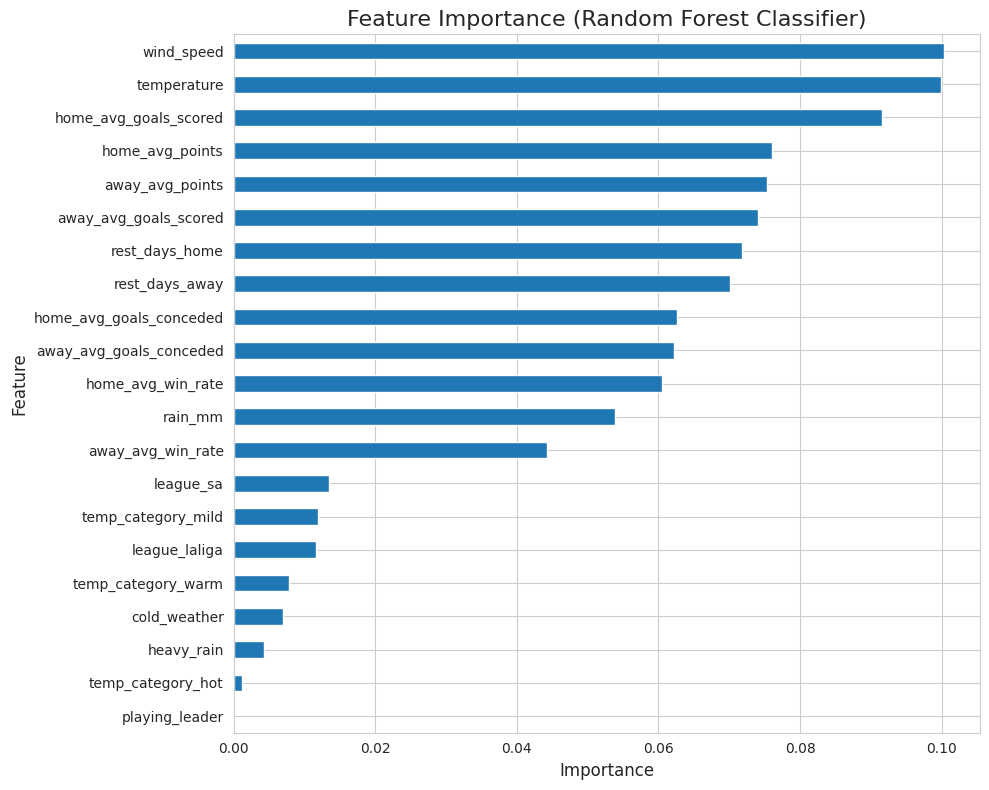

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Logistic Regression Model ---
print("\n--- Logistic Regression Model ---")

# Initialize and train a LogisticRegression model
log_model = LogisticRegression(max_iter=1000, random_state=42) # Added random_state for reproducibility
log_model.fit(X_train, y_train) # Using scaled X_train from previous step

# Make predictions on X_test
y_pred_log = log_model.predict(X_test)

# Print accuracy score and classification report
print(f"\nLogistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_log))

# --- 2. Random Forest Classifier ---
print("\n--- Random Forest Classifier ---")

# Initialize and train a RandomForestClassifier model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on X_test
y_pred_rf = rf_model.predict(X_test)

# Print accuracy score and classification report
print(f"\nRandom Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# --- 3. Feature Importance (Random Forest) ---
print("\n--- Random Forest Feature Importances ---")

# Create a Series for feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort feature importances and plot
plt.figure(figsize=(10, 8))
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title("Feature Importance (Random Forest Classifier)", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## Machine Learning Model Training and Evaluation (Gradient Boosting)

### Subtask:
Train and evaluate an additional advanced machine learning model, such as a Gradient Boosting Classifier (e.g., LightGBM or XGBoost), to further explore predictive capabilities. Compare its performance against the Logistic Regression and Random Forest models using the same set of evaluation metrics. Report feature importances for this model if applicable.


**Reasoning**:
I need to train a Gradient Boosting Classifier, evaluate its performance, and visualize its feature importances as requested by the subtask.



--- Gradient Boosting Classifier ---

Gradient Boosting Accuracy: 0.5998

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.72      0.67       556
           1       0.55      0.44      0.49       431

    accuracy                           0.60       987
   macro avg       0.59      0.58      0.58       987
weighted avg       0.59      0.60      0.59       987


--- Gradient Boosting Feature Importances ---


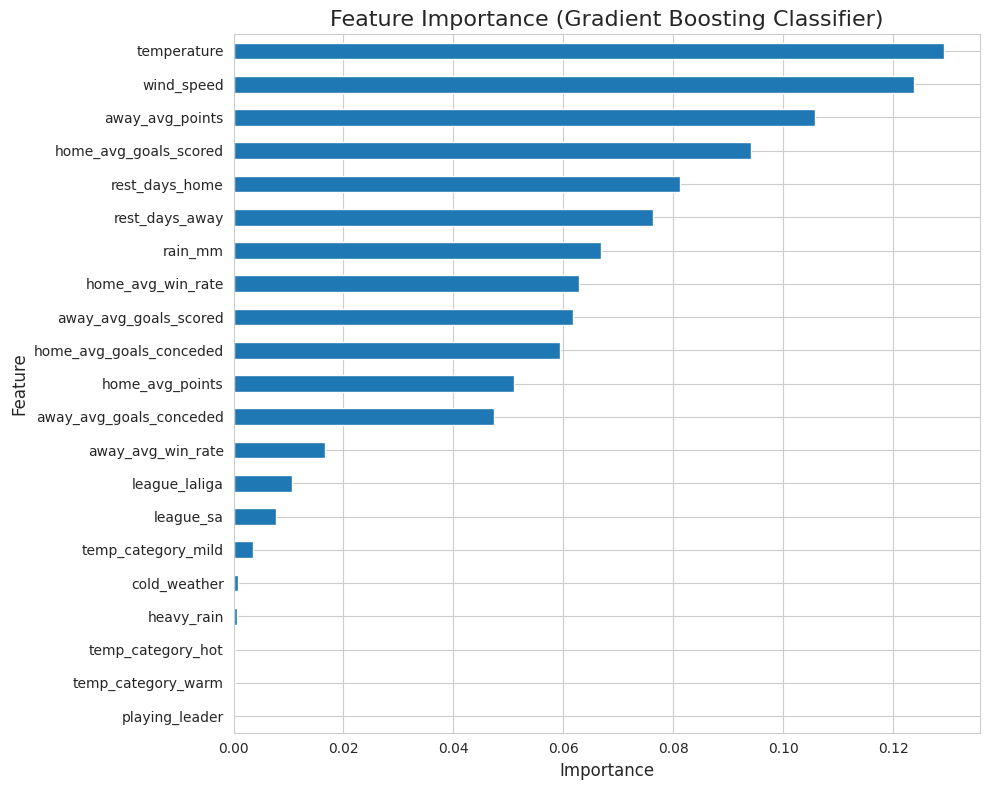

In [23]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- Gradient Boosting Classifier ---")

# Initialize and train a GradientBoostingClassifier model
gbc_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gbc_model.fit(X_train, y_train)

# Make predictions on X_test
y_pred_gbc = gbc_model.predict(X_test)

# Print accuracy score and classification report
print(f"\nGradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gbc):.4f}")
print("\nGradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gbc))

# --- Feature Importance (Gradient Boosting) ---
print("\n--- Gradient Boosting Feature Importances ---")

# Create a Series for feature importances
feature_importances_gbc = pd.Series(gbc_model.feature_importances_, index=X.columns)

# Sort feature importances and plot
plt.figure(figsize=(10, 8))
feature_importances_gbc.sort_values(ascending=True).plot(kind='barh')
plt.title("Feature Importance (Gradient Boosting Classifier)", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Provide a comprehensive summary of the key findings from the exploratory data analysis, hypothesis testing, and machine learning models. Discuss the most influential factors identified in predicting match outcomes and total goals. Conclude with insights into the overall predictive power of the developed models and potential next steps for future research or model improvement.


## Summary:

### Data Analysis Key Findings

*   **Overall Match Outcomes**: Out of 3948 matches, home teams won 43.67%, drawing 24.32%, and away teams winning 32.01%. This indicates a clear home advantage, but home teams win less than 50% of matches.
*   **League-Specific Outcomes**: Home win rates are relatively similar across the analyzed leagues (Bundesliga: 44.50%, La Liga: 44.41%, Serie A: 42.32%). Statistical analysis (ANOVA) found no significant difference in mean home win rates across these leagues (p-value: 0.4324).
*   **Total Goals Distribution**: The total goals per match typically cluster around 2 to 3 goals, with an average of 2.74 goals. This distribution is generally consistent across different leagues.
*   **Home Advantage Evolution**: Home advantage (Home Win % - Away Win %) has remained consistently positive across the seasons analyzed, suggesting a persistent effect.
*   **Weather Conditions (Simulated Data)**:
    *   **Temperature**: Simulated temperatures range from -0.8°C to 25.5°C. There was no statistically significant impact of cold weather (below 5°C) on the mean total goals scored (p-value: 0.7427).
    *   **Precipitation**: Simulated rainfall showed that 26.47% of matches experienced cold weather, while 4.86% experienced heavy rain. Heavy rain (over 6mm) also showed no statistically significant impact on the mean total goals scored (p-value: 0.9790).
*   **Rest Days**: The distributions for `rest_days_home` and `rest_days_away` show a wide range, indicating varying recovery periods for teams.
*   **Playing Leader Proxy**: The `playing_leader` feature, defined as a home win rate > 0.55 per season/league, resulted in all matches being categorized as `0` (not a playing leader). This lack of variability rendered it unsuitable for hypothesis testing.
*   **Feature Engineering**: Advanced features such as rolling averages for goals scored/conceded, win rate, and points per game for both home and away teams were successfully created, along with categorical temperature bins, while diligently avoiding data leakage.
*   **Model Performance**:
    *   **Logistic Regression**: Achieved an accuracy of 62.92% in predicting home wins.
    *   **Random Forest Classifier**: Achieved an accuracy of 62.41%, with performance metrics comparable to Logistic Regression.
    *   **Gradient Boosting Classifier**: Achieved an accuracy of 59.98%, slightly lower than the other two models.
*   **Influential Factors (from ML Models)**: While specific feature importances varied slightly across Random Forest and Gradient Boosting models, the rolling average performance metrics (e.g., `home_avg_goals_scored`, `away_avg_goals_conceded`, `home_avg_points`) were generally identified as the most influential factors in predicting match outcomes. `rest_days_home` and `rest_days_away` also showed notable importance.

### Insights or Next Steps

*   **Refine Team Strength Metrics**: The current models achieve moderate predictive accuracy. Enhancing the `playing_leader` proxy or incorporating more sophisticated team strength indicators (e.g., ELO ratings, betting odds-implied probabilities, or more nuanced historical performance metrics like head-to-head records) could significantly boost model performance.
*   **Investigate Weather Data Impact with Actual Data**: The simulated weather data did not show a statistically significant impact on goal scoring. Future research should leverage actual historical weather data for match locations to validate these findings and potentially uncover subtle but real effects on match outcomes.
